In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

In [2]:
def read_nfixedpoints_file(filepath):
    data = np.loadtxt(filepath, comments='#')
    return data

In [3]:
def plot_nfixedpoints_gnuplot(data, val_filter, param_list_to_plot, pos_filter=0, 
                              pos_param=1, pos_xplot=2, plot_title=None,
                              xmin=None, xmax=None, ymin=None, ymax=None,
                              figsize=(8, 6), dpi=150, legend_loc='best', ncols_legend=1,
                              xlabel=None, ylabel=None, title_fontsize=18, label_fontsize=20,
                              tick_fontsize=14, legend_fontsize=14, save_to=None,
                              markersize=8, linewidth=2, markers=None, tol=1e-9,
                              color_offset=0, legend_title=None, 
                              label_param="N", type_param=int, logscalex=True, 
                              logscaley=False):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    if markers is None:
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<', '>']

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.subplots_adjust(left=0.15, bottom=0.14, right=0.98, top=0.92)

    mask_filter = np.isclose(data[:, pos_filter], val_filter, atol=tol)
    data_filtered = data[mask_filter]

    for idx, param in enumerate(param_list_to_plot):
        color = color_cycle[(idx + color_offset) % len(color_cycle)]
        marker = markers[idx % len(markers)]

        mask_param = data_filtered[:, pos_param] == param
        sub = data_filtered[mask_param]
        if len(sub) == 0:
            continue
        sub = sub[np.argsort(sub[:, pos_xplot])]
        xdata = sub[:, pos_xplot]
        nfixedpoints_norm = sub[:, 3] / sub[:, 2]
        error = sub[:, 4] / sub[:, 2]

        ax.plot(xdata, nfixedpoints_norm, marker=marker, linestyle='-', linewidth=linewidth,
                markersize=markersize, label=rf'{label_param}={type_param(param)}', 
                color=color)
        ax.errorbar(xdata, nfixedpoints_norm, yerr=error, fmt='none', ecolor=color, elinewidth=1.5, capsize=3)
    if logscalex:
        ax.set_xscale('log')
    if logscaley:
        ax.set_yscale('log')
    ax.set_xlabel(xlabel if xlabel is not None else r"$n_{\rm init}$", fontsize=label_fontsize)
    ax.set_ylabel(ylabel if ylabel is not None else r"$n_{\rm fixed}/n_{\rm init}$", fontsize=label_fontsize)
    ax.set_title(plot_title if plot_title is not None else rf"$\mu={val_filter}$", fontsize=title_fontsize)

    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5,
              ncol=ncols_legend, title=legend_title)

    if save_to is not None:
        plt.savefig(save_to)
    plt.show()

In [4]:
path_in = "/run/media/david/Data/Research/Ecology/Results/IBMF/Counting_fixed_points"

# $\sigma=0.000$

In [5]:
eps = "0.000"
sigma = "0.000"
filein = f"IBMF_T0_seq_gr_inside_RRG_eps_{eps}_sigma_{sigma}_c_3_Lotka_Volterra_final_av0_0.500_dn_0.500_tol_1.0e-06_maxiter_10000_damping_1.00_nfixedpoints_avg.txt"
path_nfixedpoints = f"{path_in}/{filein}"

data_nfixedpoints = read_nfixedpoints_file(path_nfixedpoints)

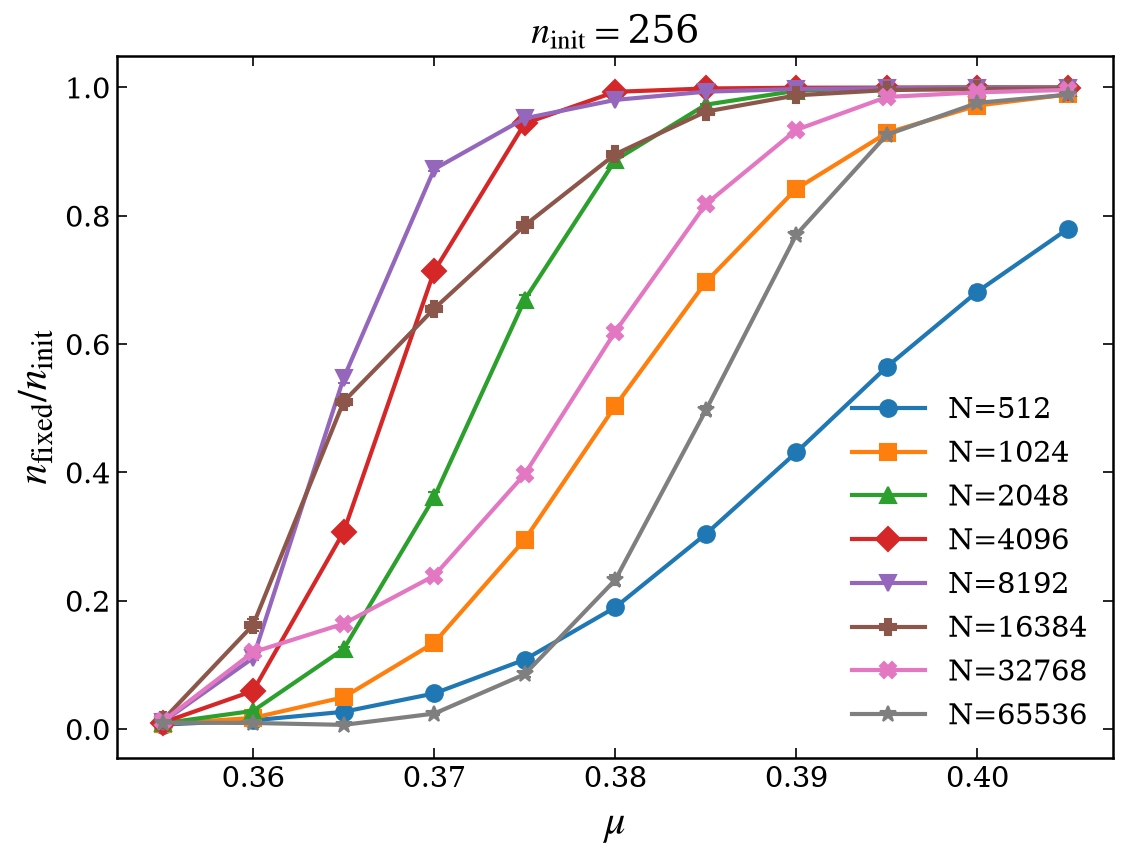

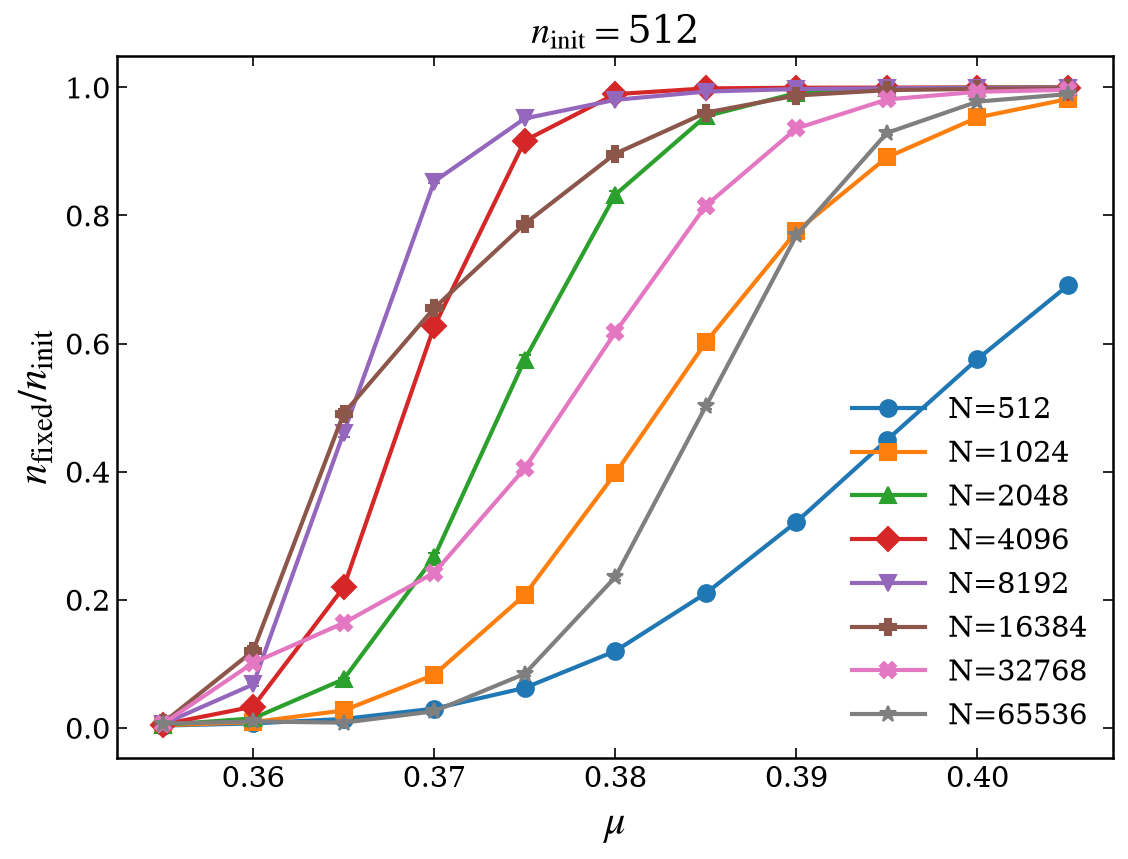

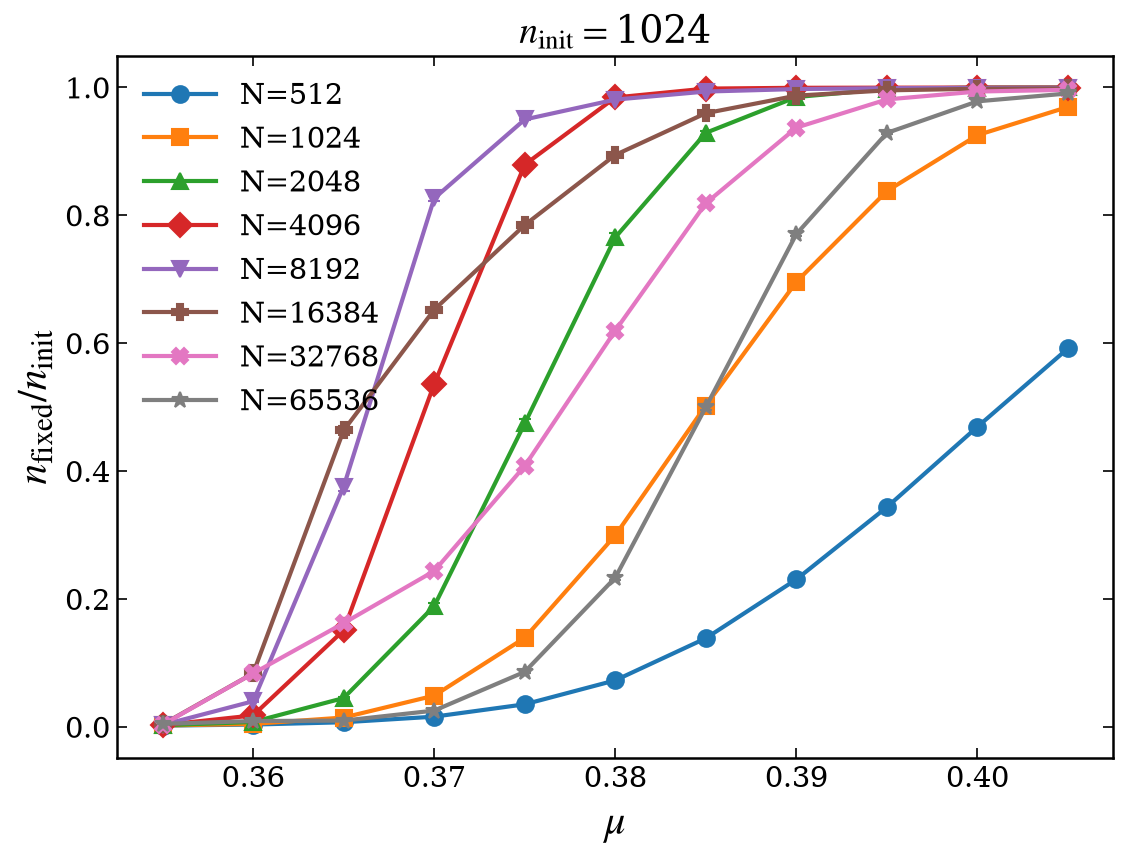

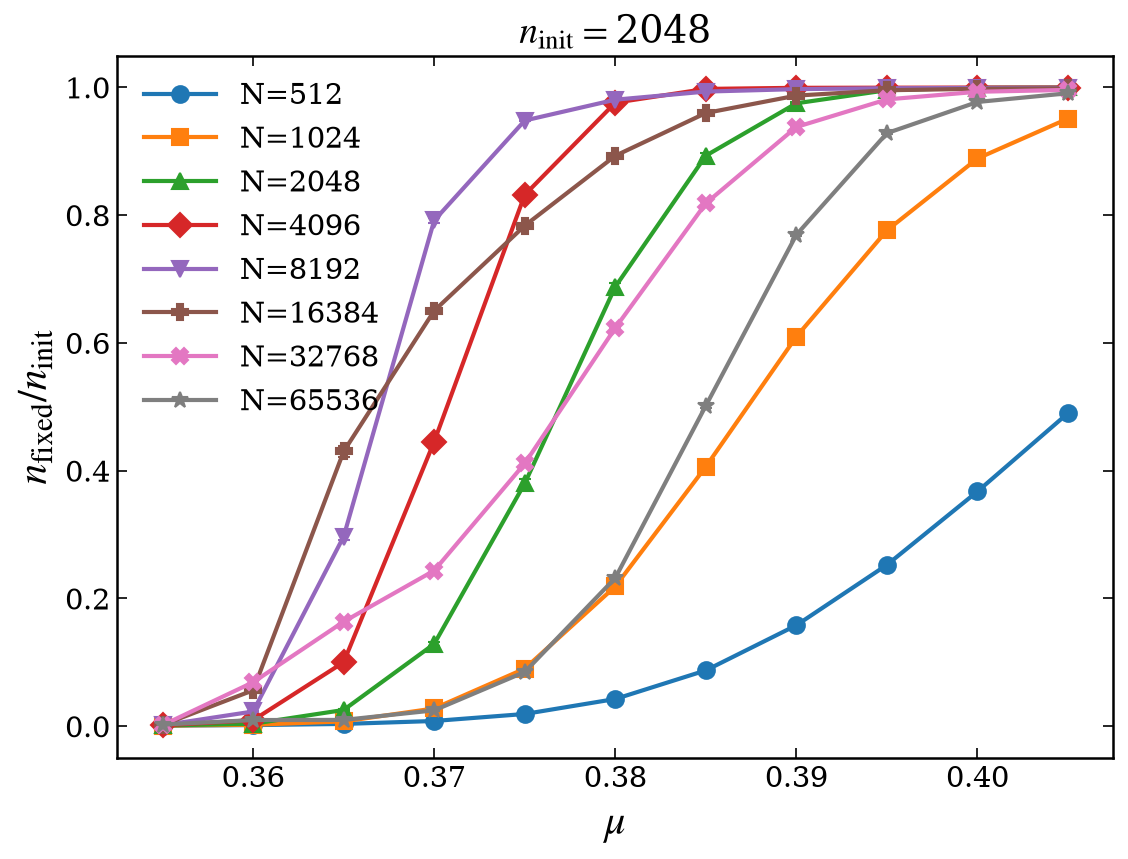

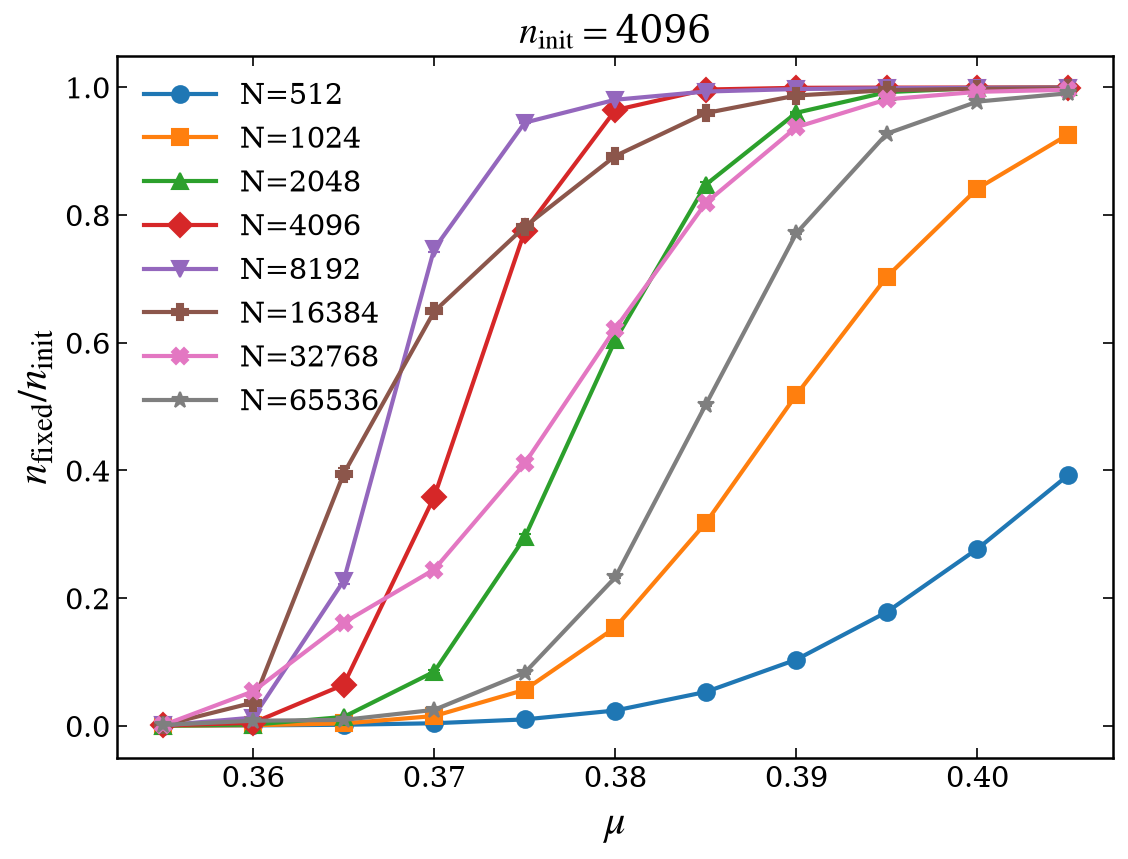

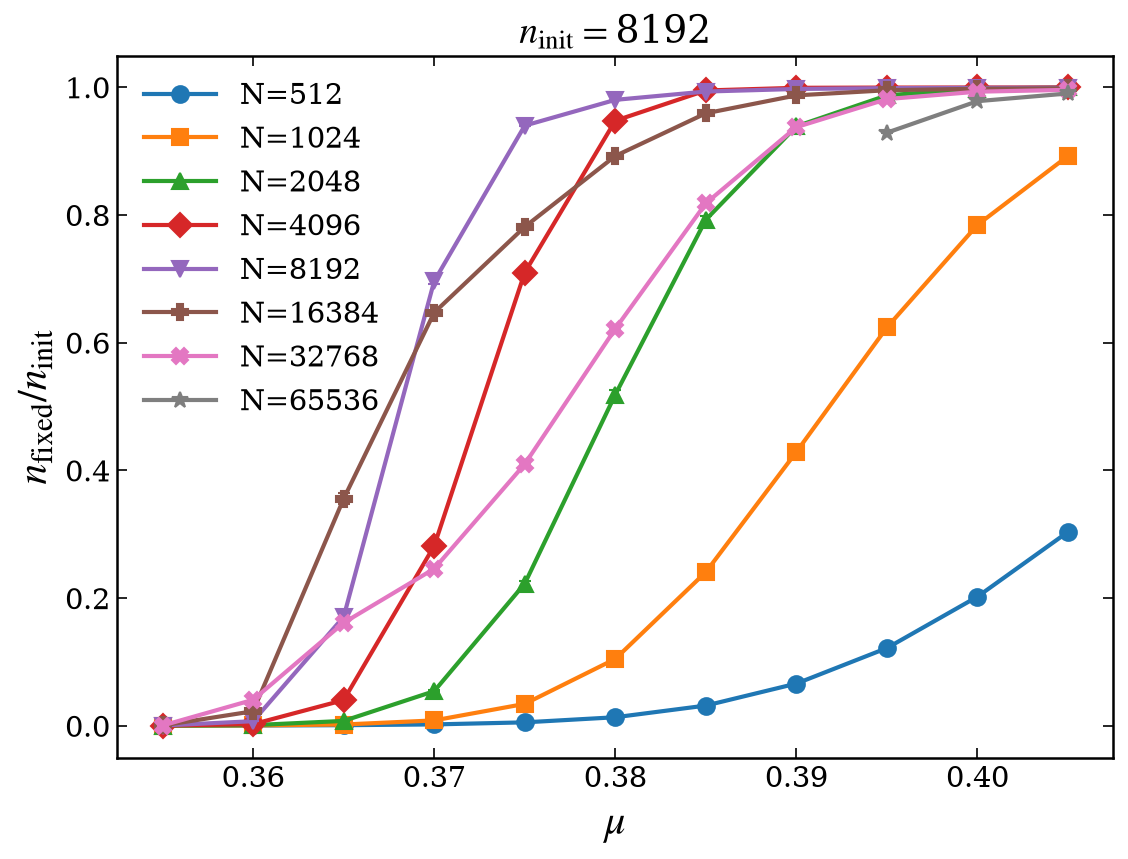

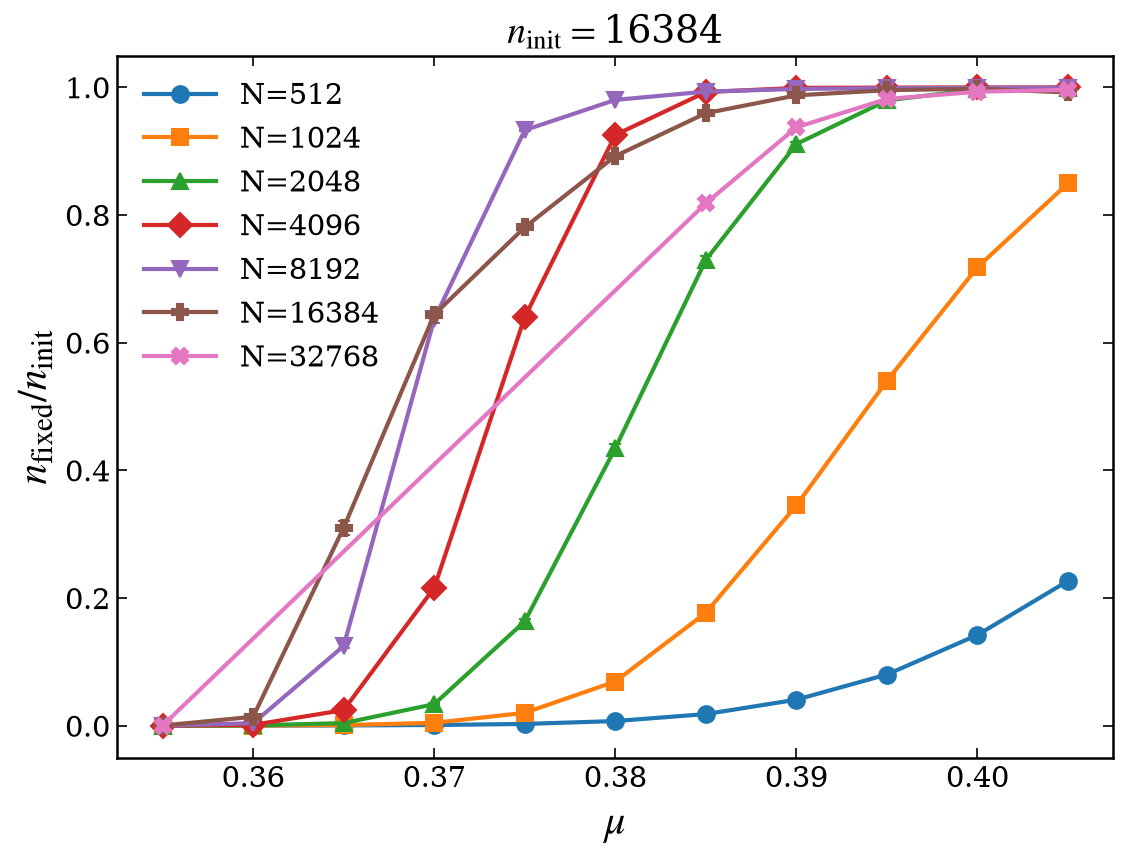

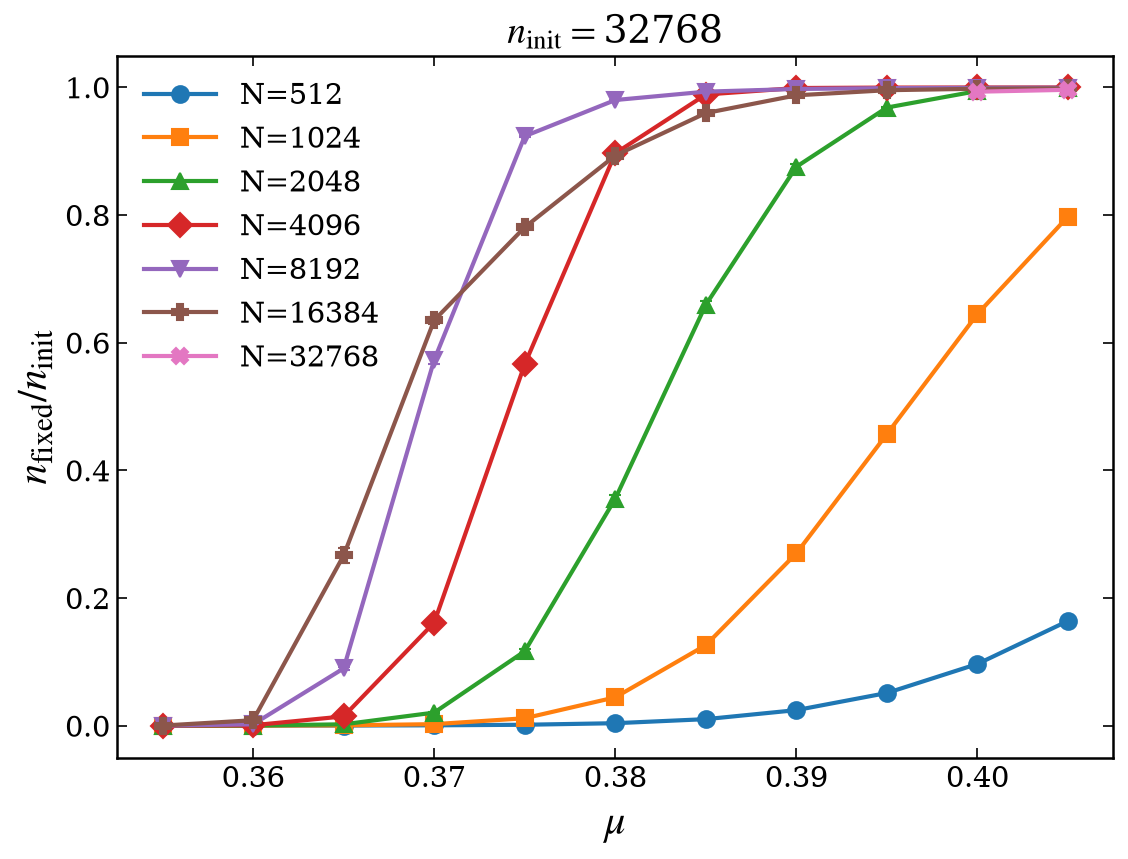

In [6]:
N_values = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]
ninitcond_values = np.unique(data_nfixedpoints[:, 2])

for ninitcond in ninitcond_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, ninitcond, N_values, pos_filter=2, 
                              pos_param=1, pos_xplot=0, label_param="N", type_param=int,
                              plot_title=r"$n_{\rm init}=$" + str(int(ninitcond)),
                              xlabel=r"$\mu$", logscalex=False)

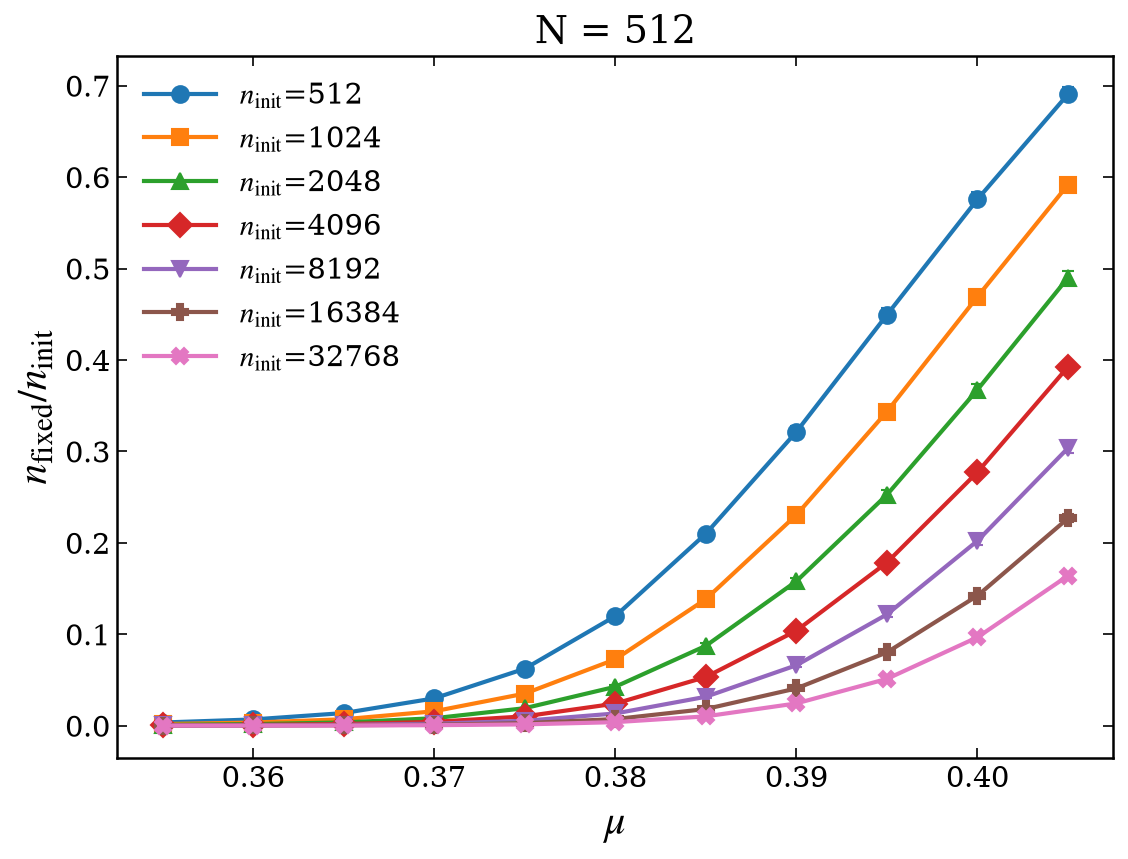

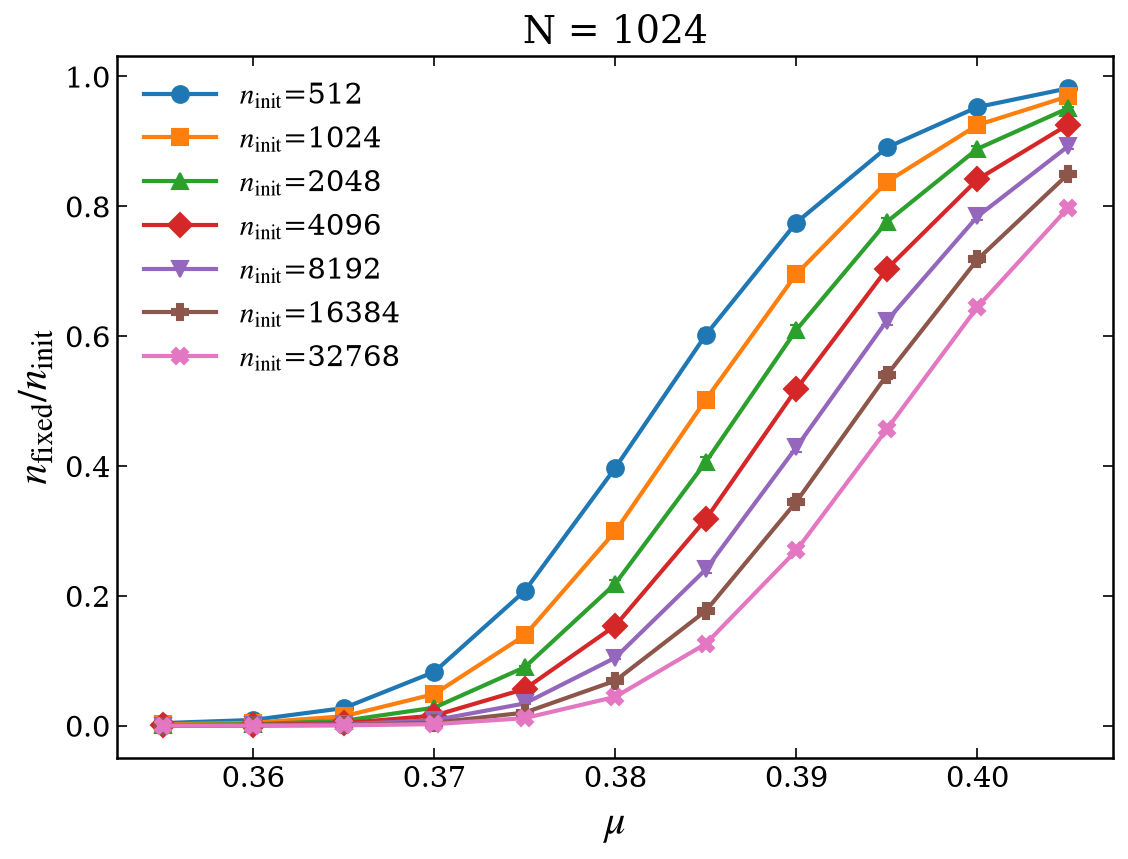

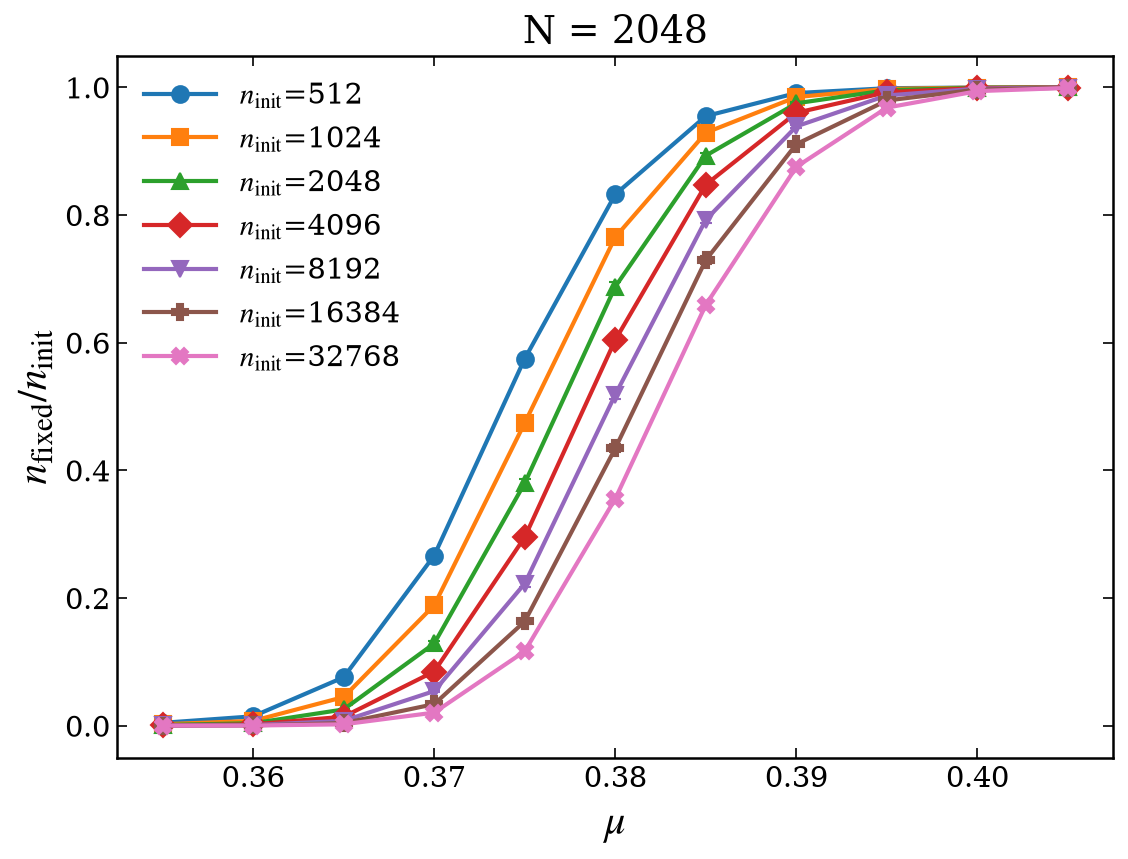

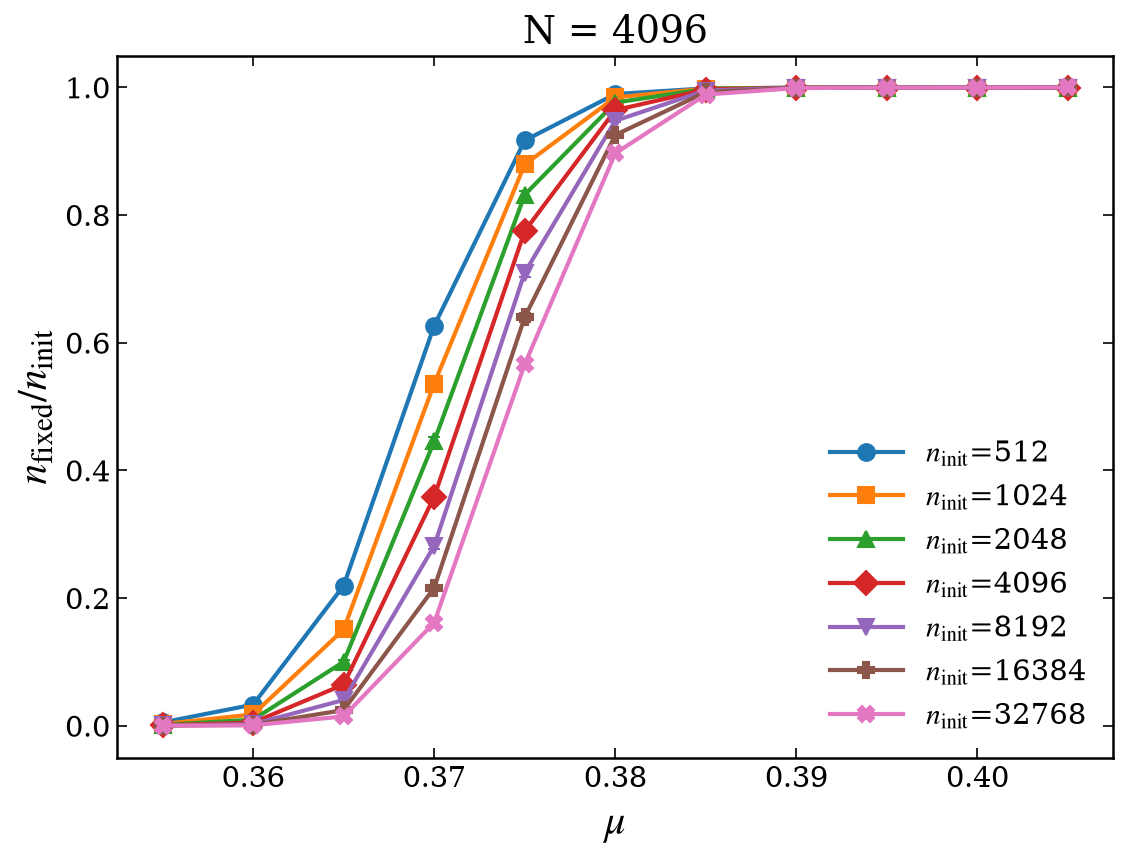

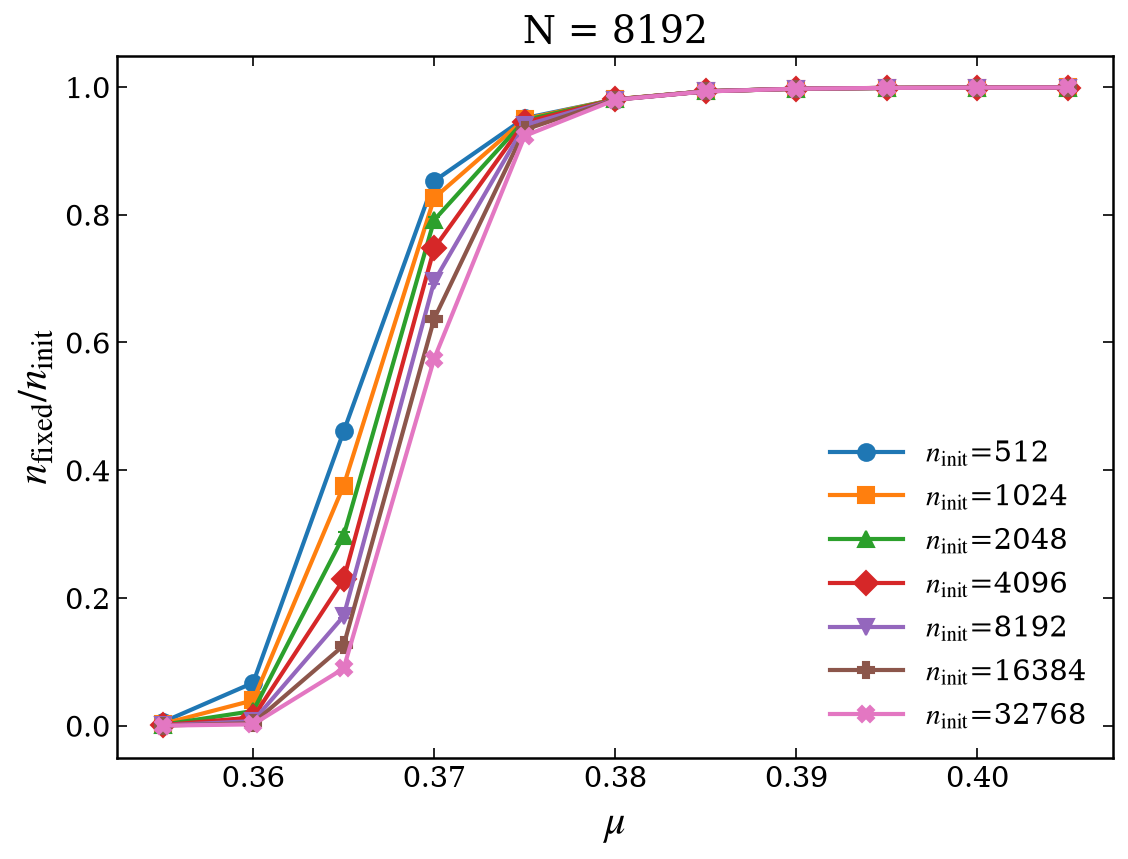

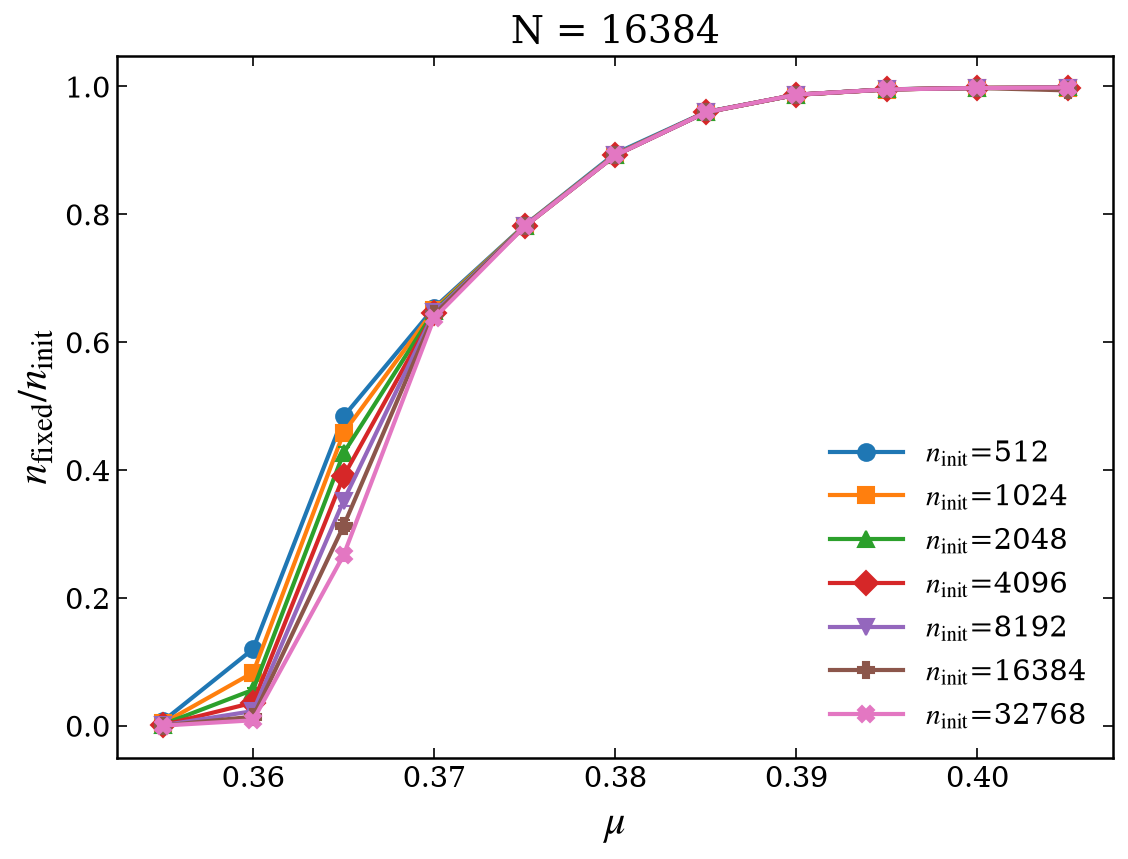

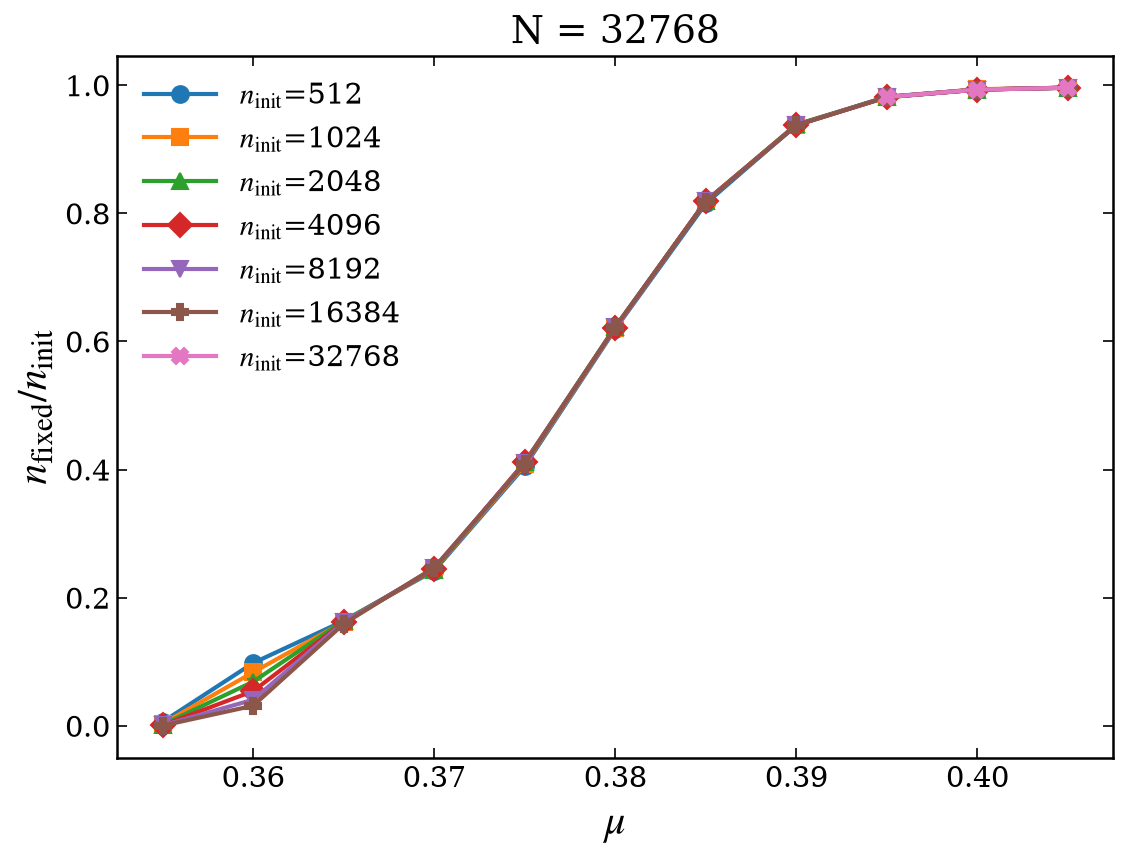

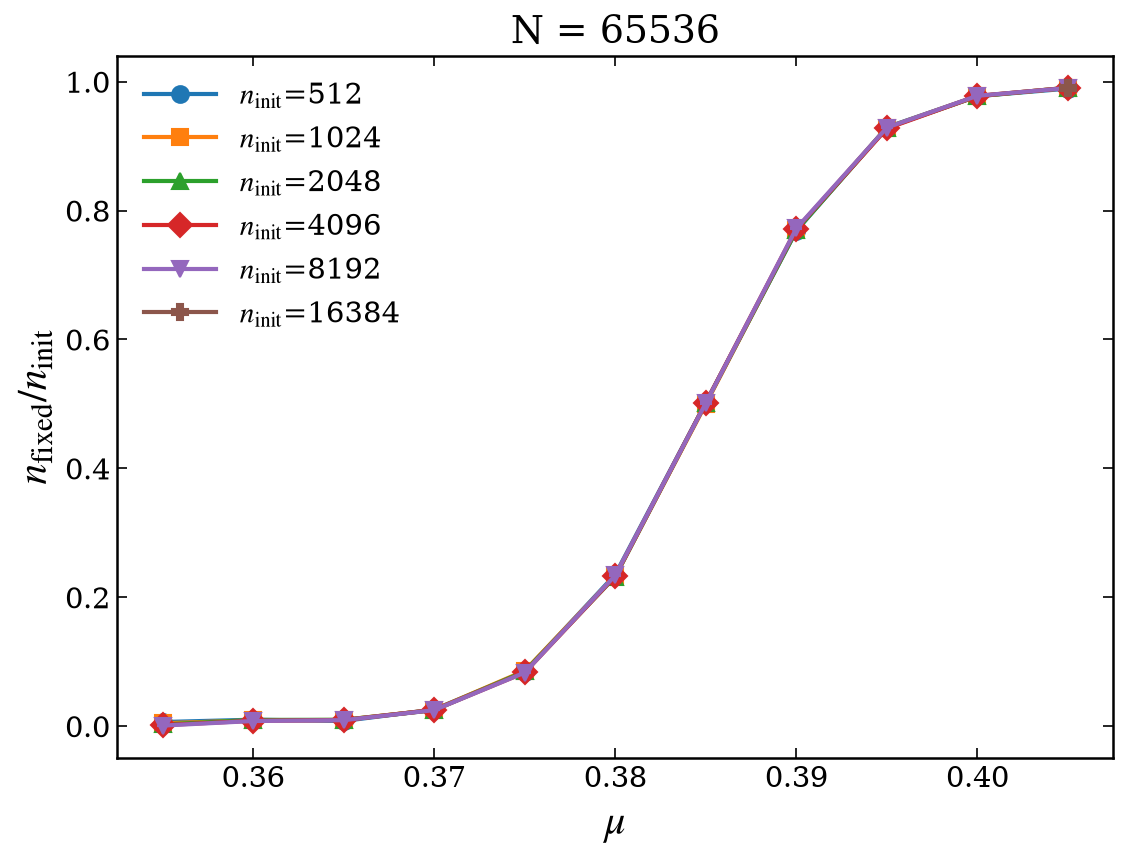

In [6]:
ninitcond_values = [512, 1024, 2048, 4096, 8192, 16384, 32768]
N_values = np.unique(data_nfixedpoints[:, 1])

for N in N_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, N, ninitcond_values, pos_filter=1, 
                              pos_param=2, pos_xplot=0, label_param=r"$n_{\rm init}$", type_param=int,
                              plot_title="N = " + str(int(N)),
                              xlabel=r"$\mu$", logscalex=False)

# $\sigma=0.150$

In [7]:
eps = "0.000"
sigma = "0.150"
filein = f"IBMF_T0_seq_gr_inside_RRG_eps_{eps}_sigma_{sigma}_c_3_Lotka_Volterra_final_av0_0.500_dn_0.500_tol_1.0e-06_maxiter_10000_damping_1.00_nfixedpoints_avg.txt"
path_nfixedpoints = f"{path_in}/{filein}"

data_nfixedpoints = read_nfixedpoints_file(path_nfixedpoints)

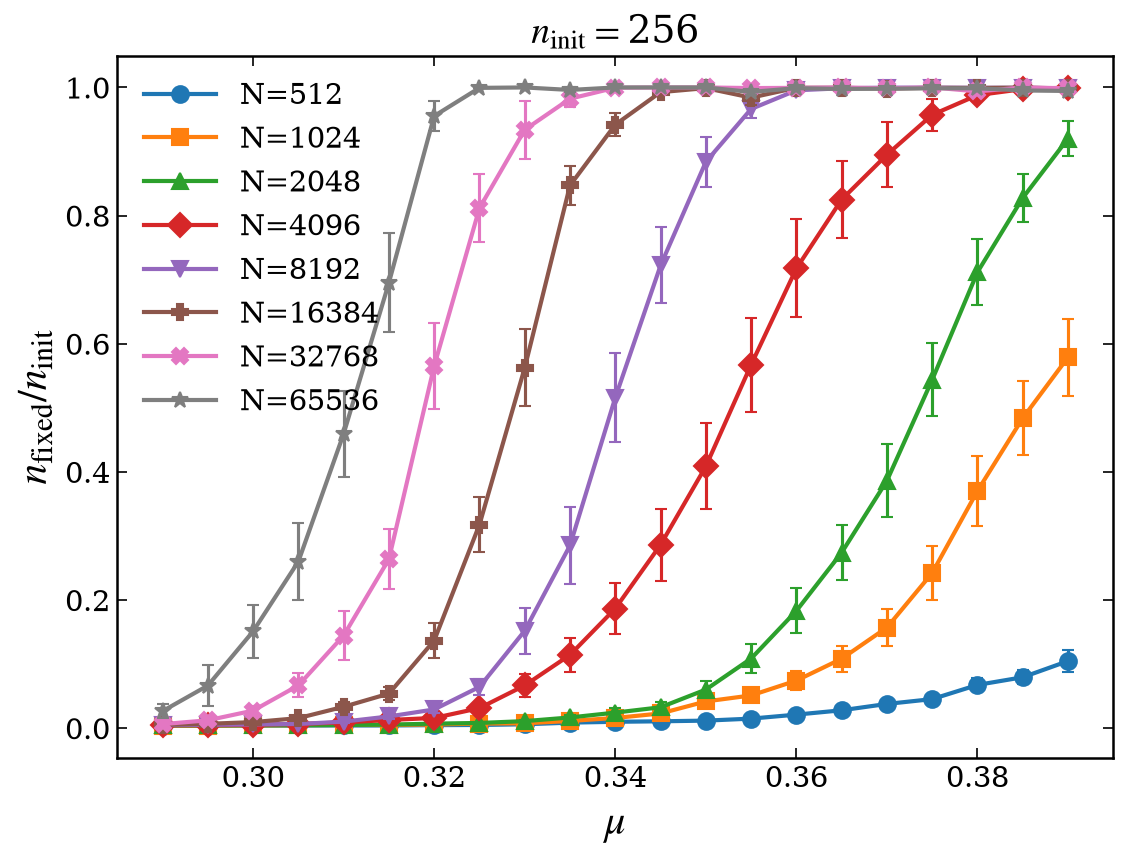

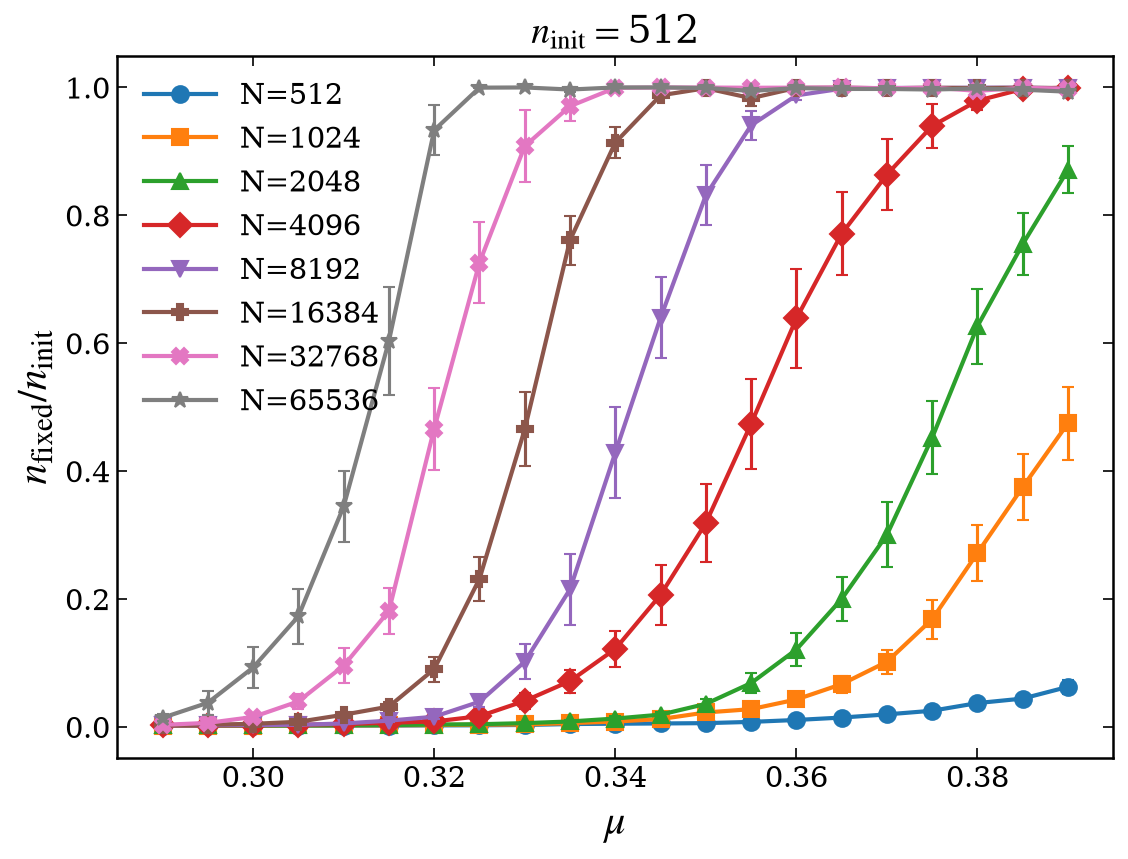

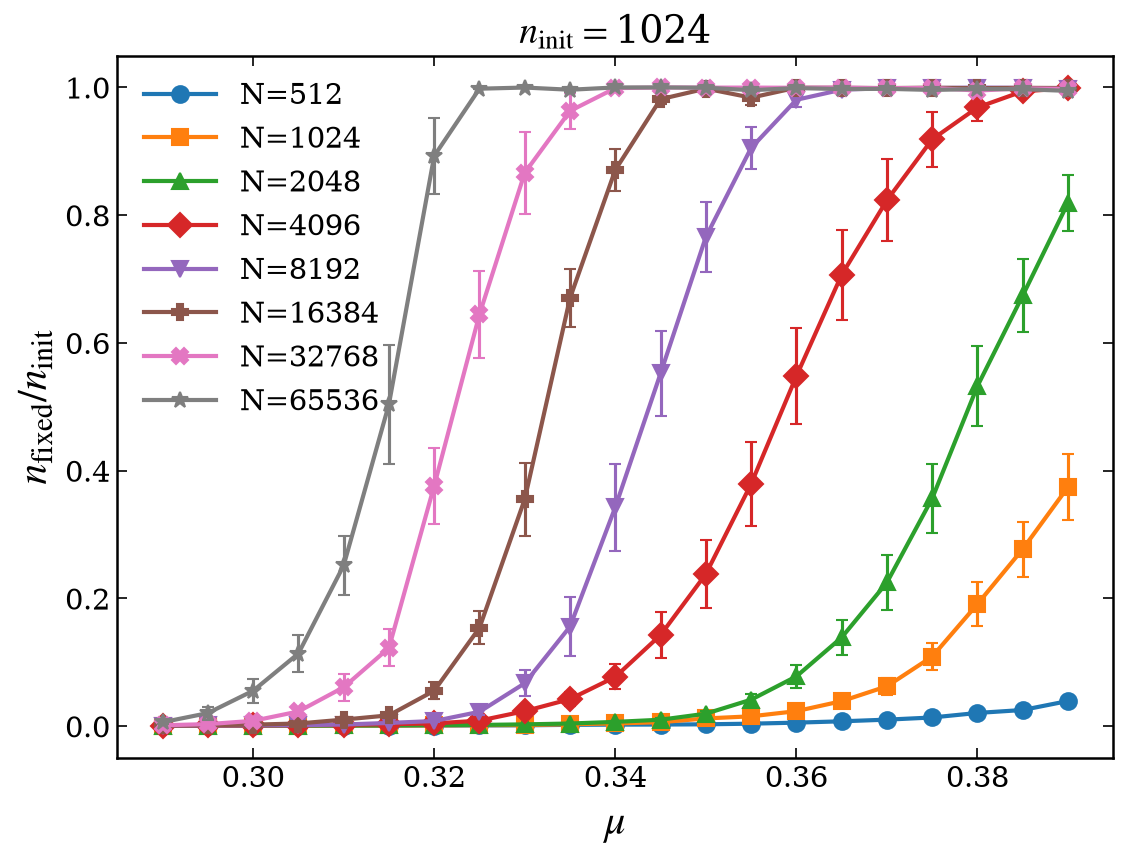

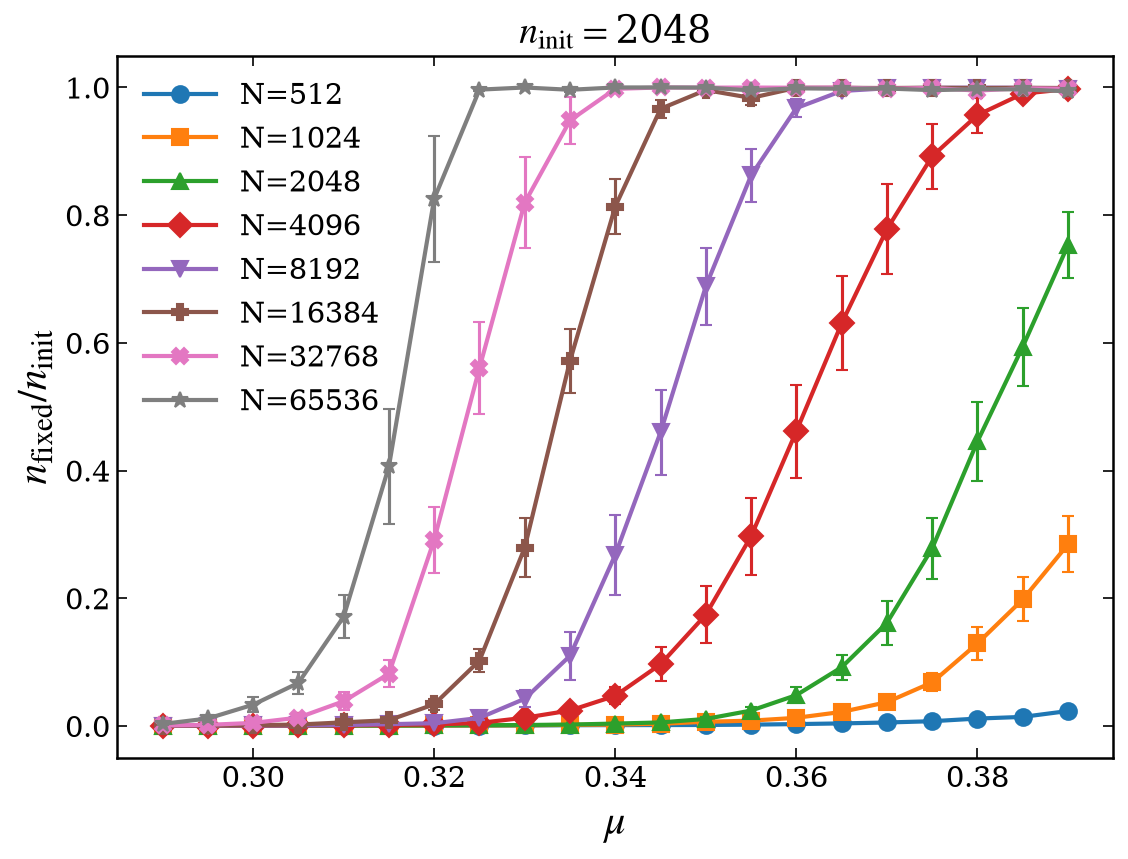

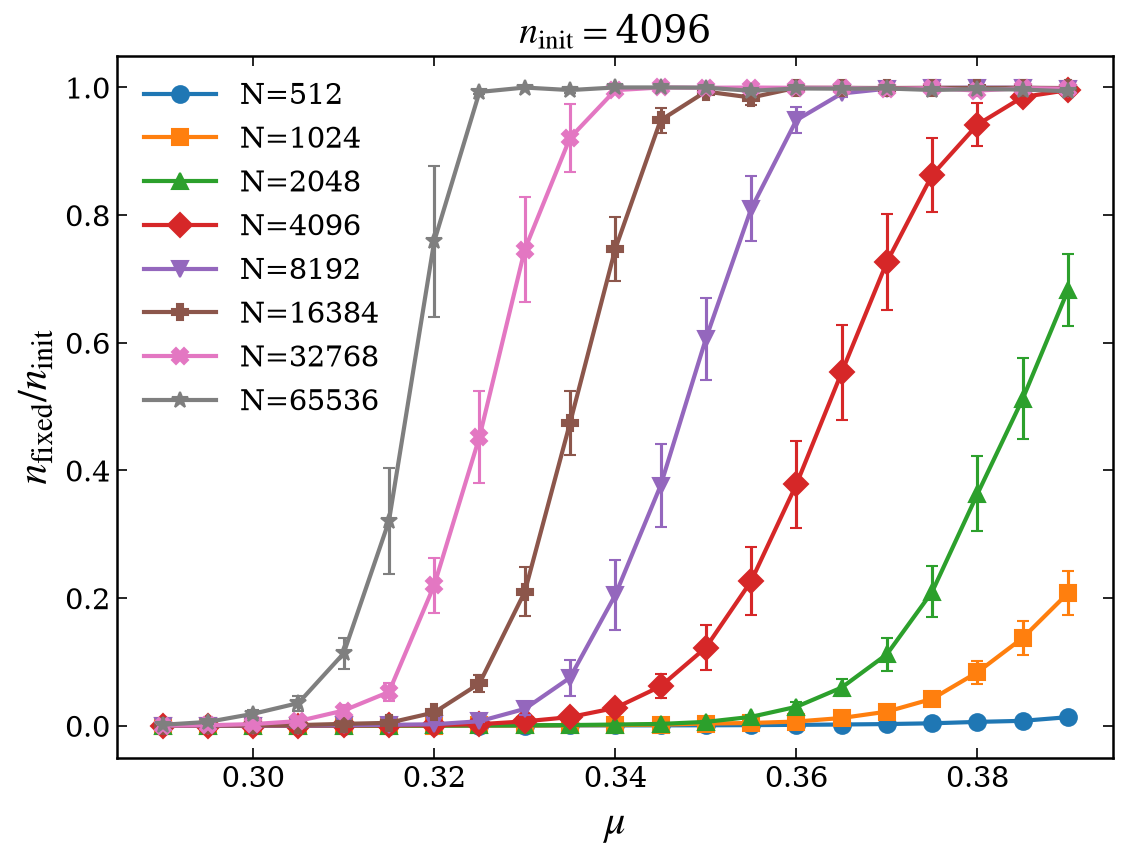

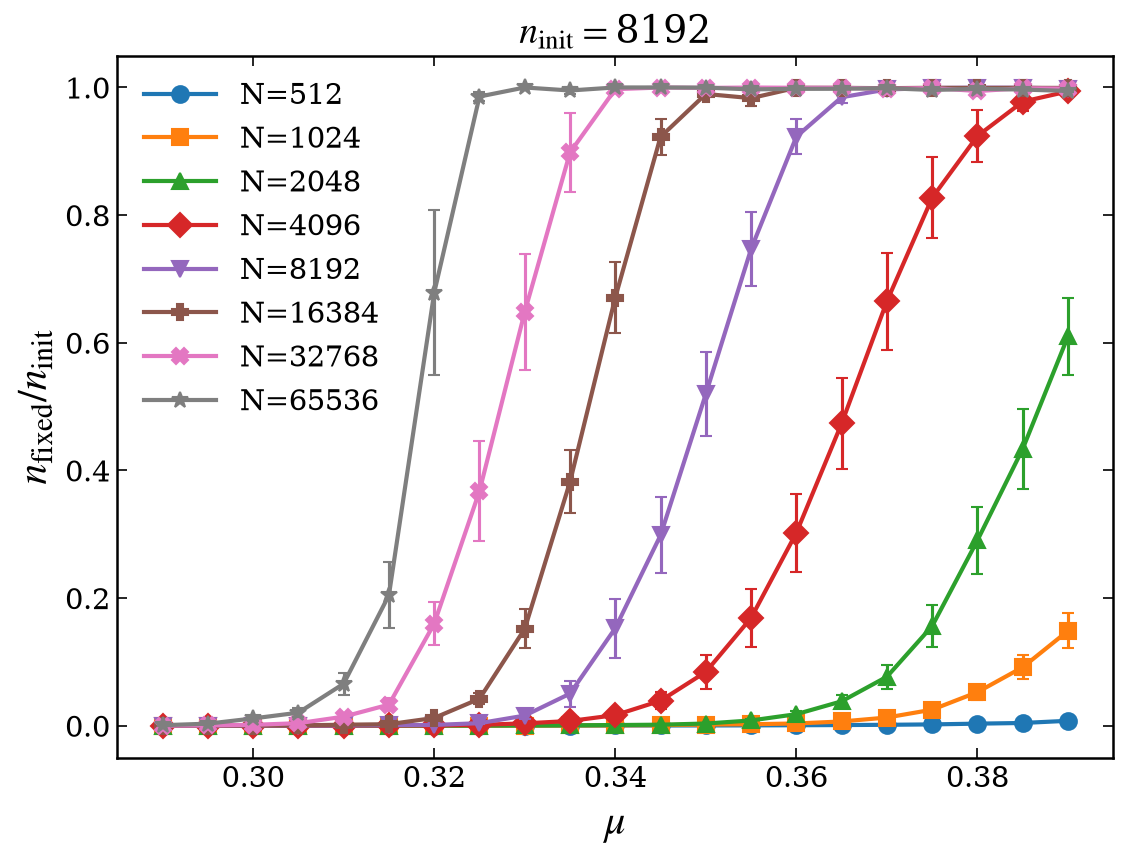

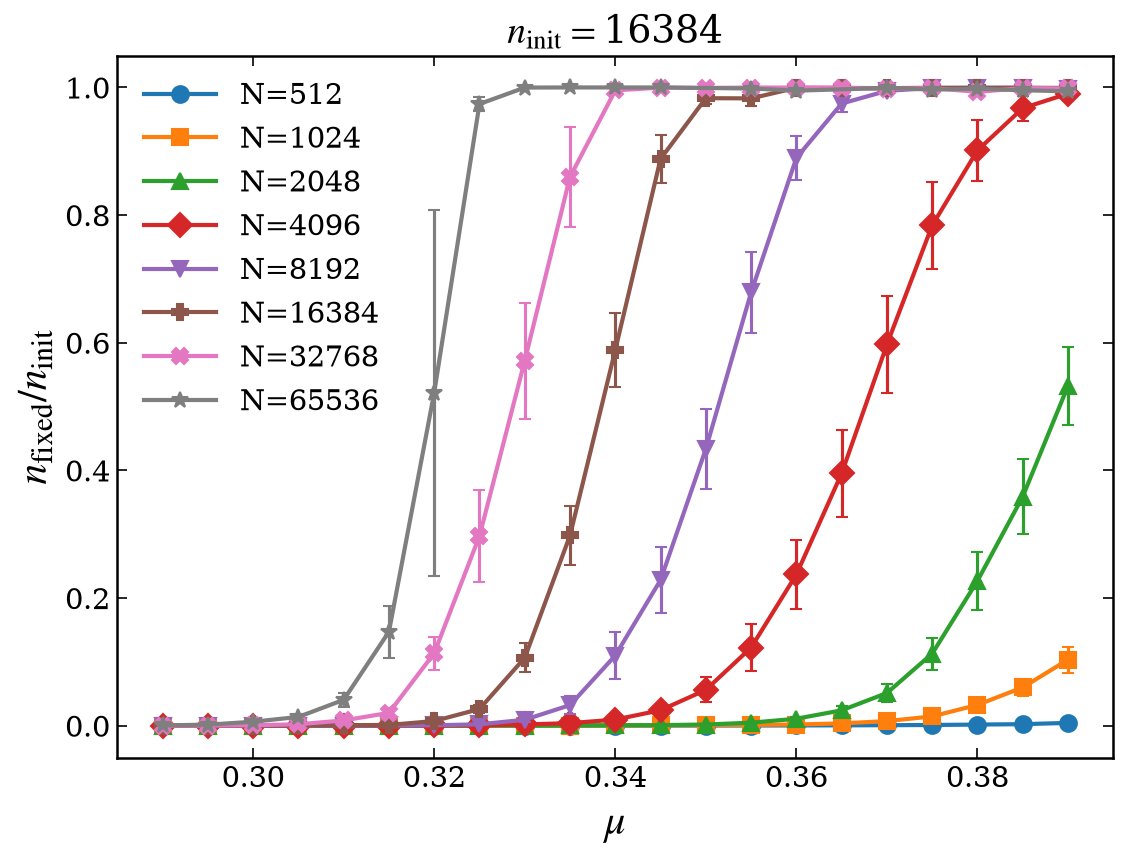

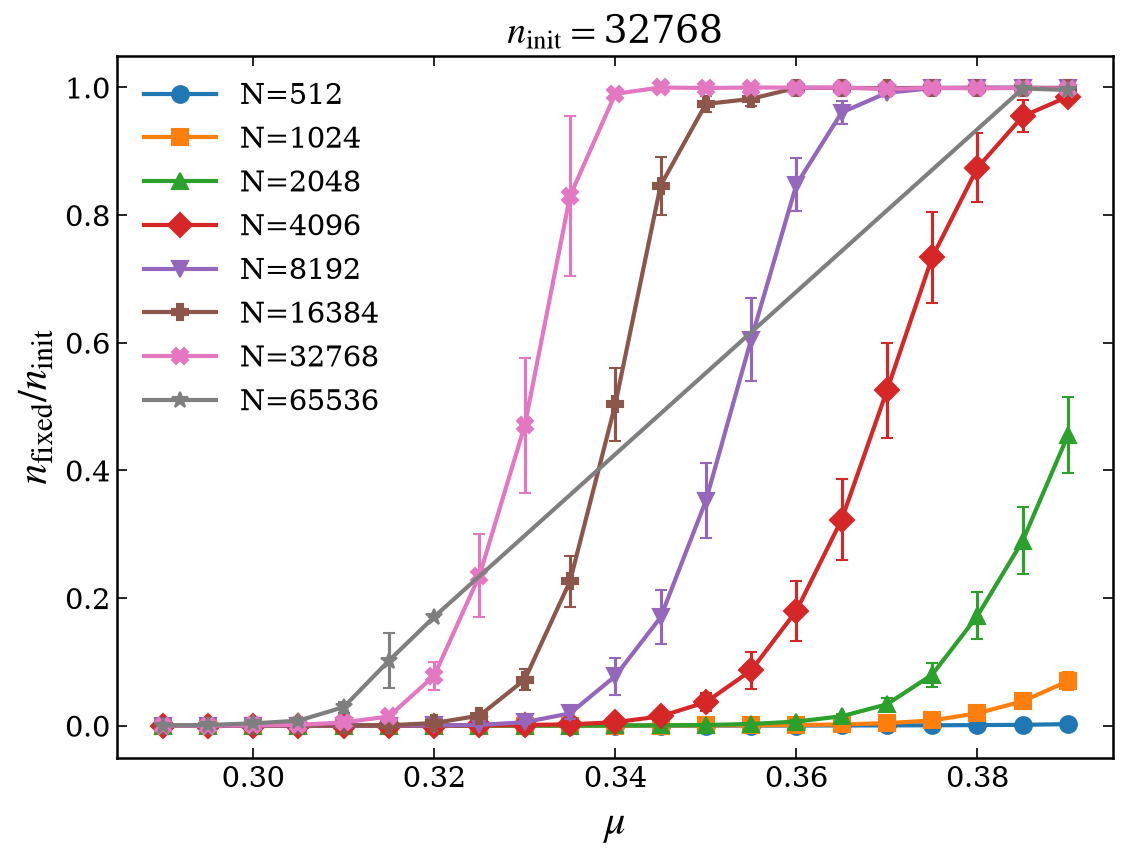

In [9]:
N_values = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]
ninitcond_values = np.unique(data_nfixedpoints[:, 2])

for ninitcond in ninitcond_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, ninitcond, N_values, pos_filter=2, 
                              pos_param=1, pos_xplot=0, label_param="N", type_param=int,
                              plot_title=r"$n_{\rm init}=$" + str(int(ninitcond)),
                              xlabel=r"$\mu$", logscalex=False)

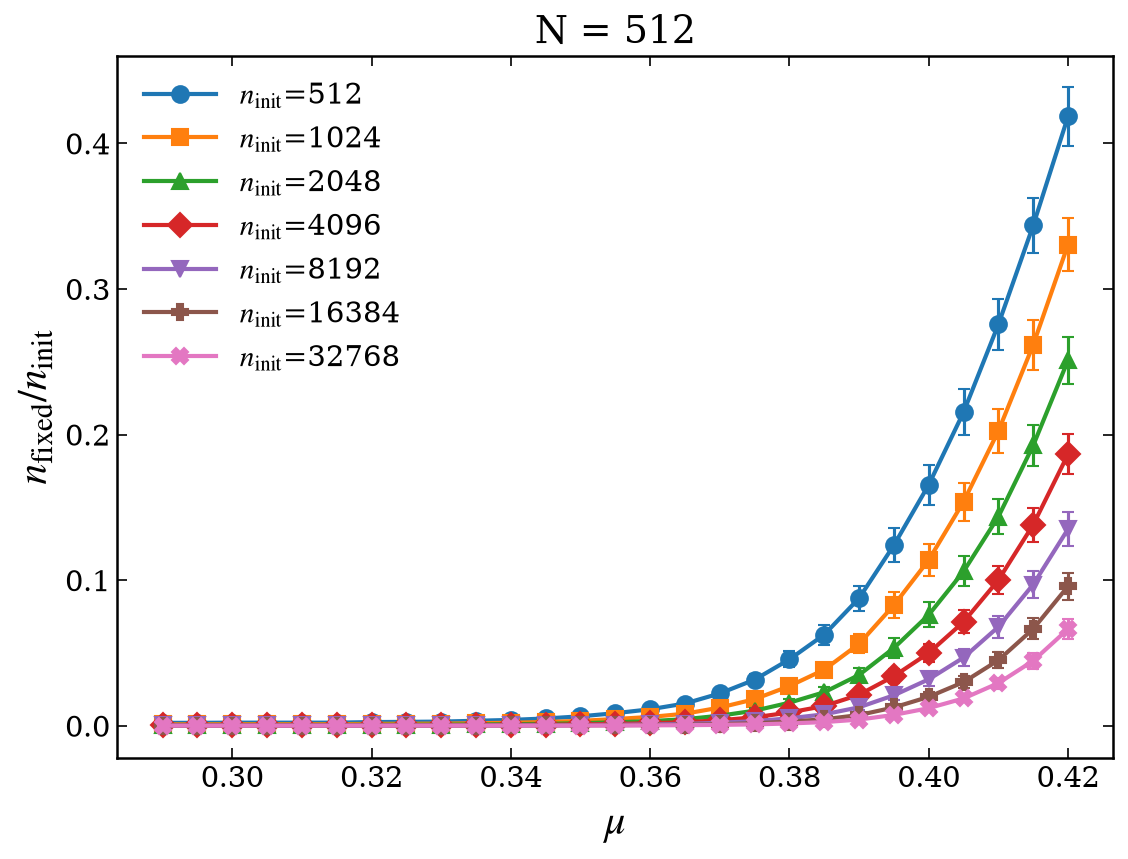

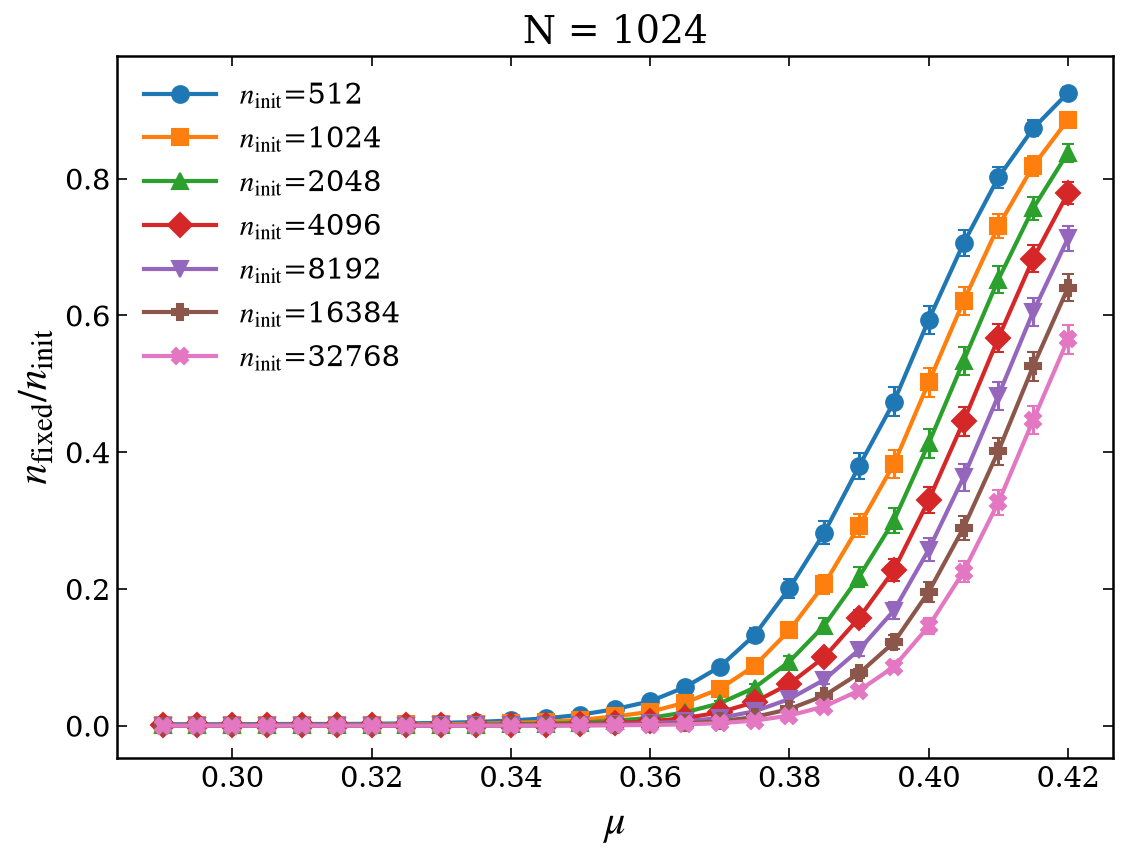

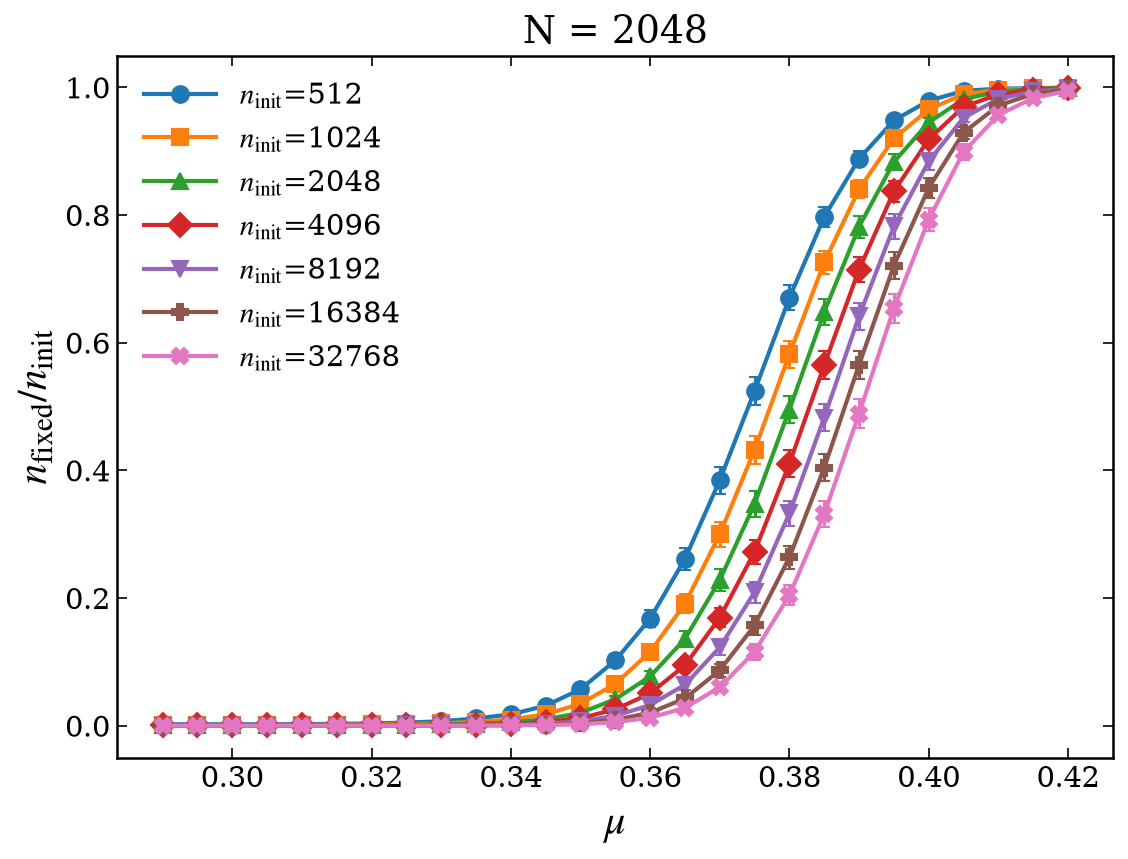

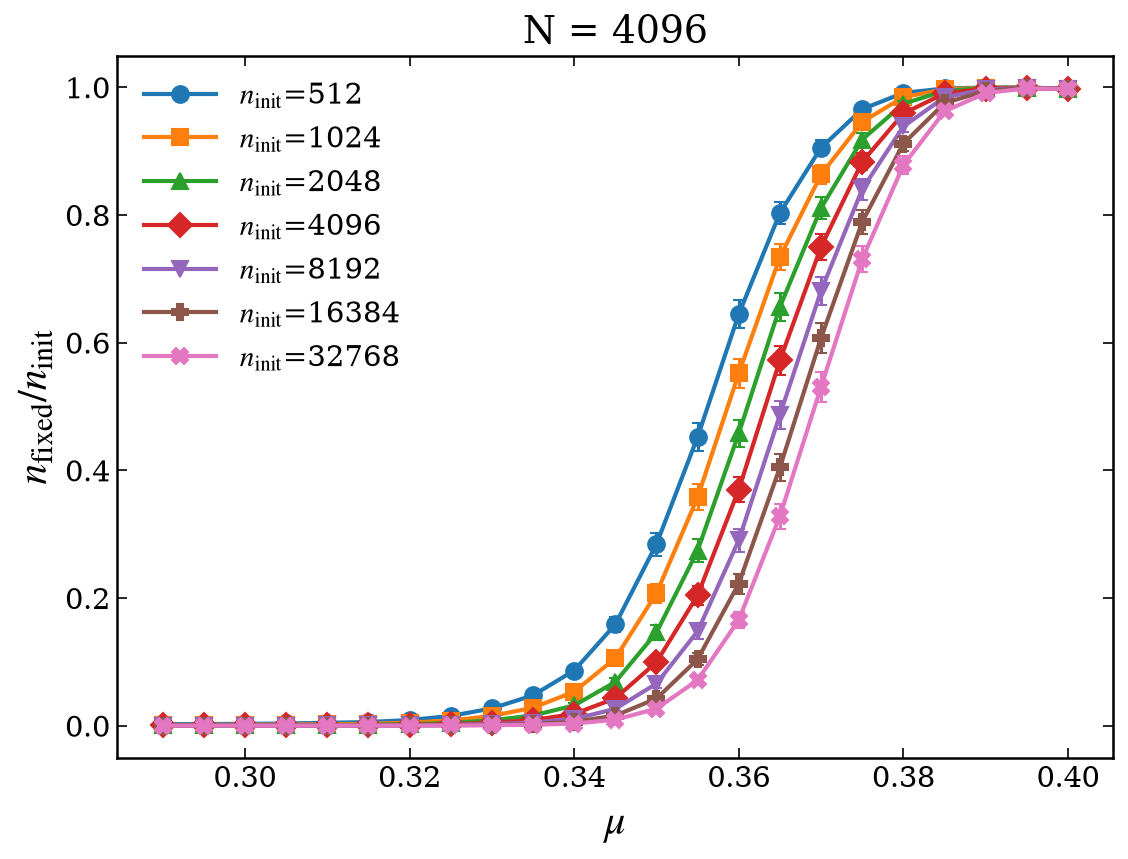

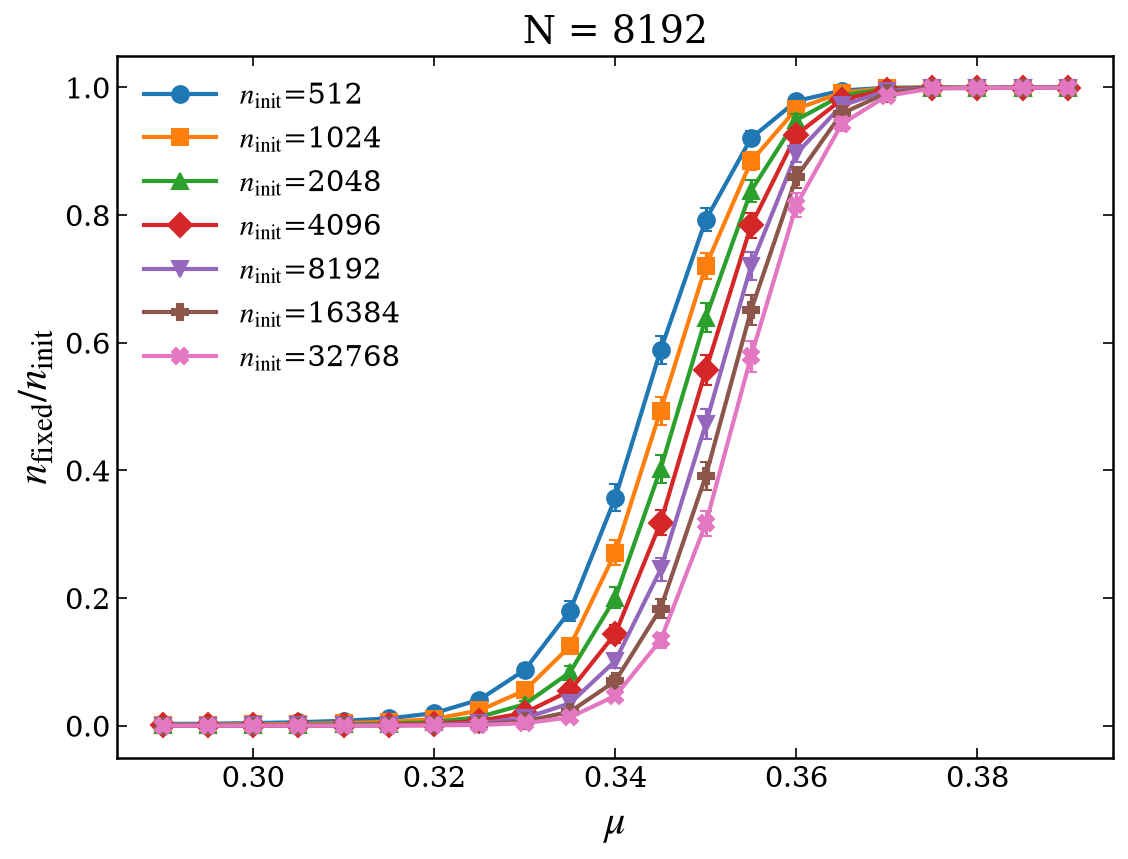

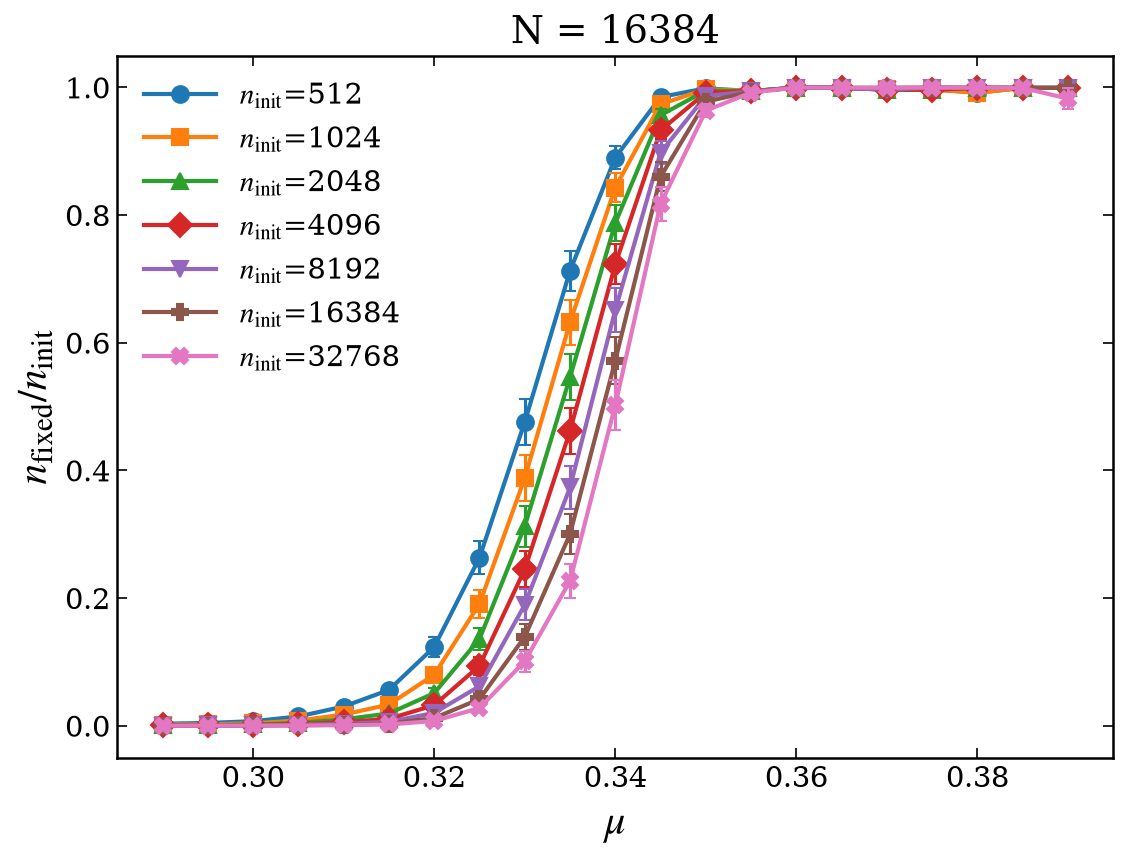

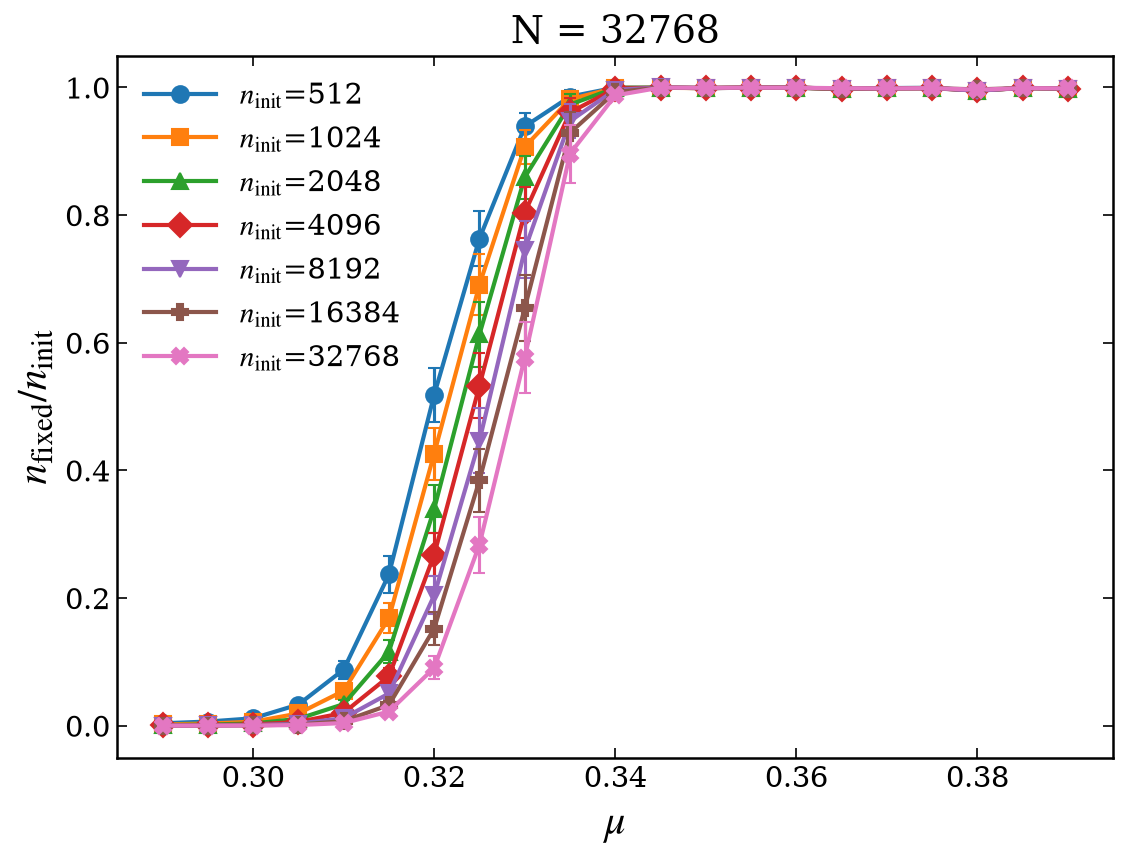

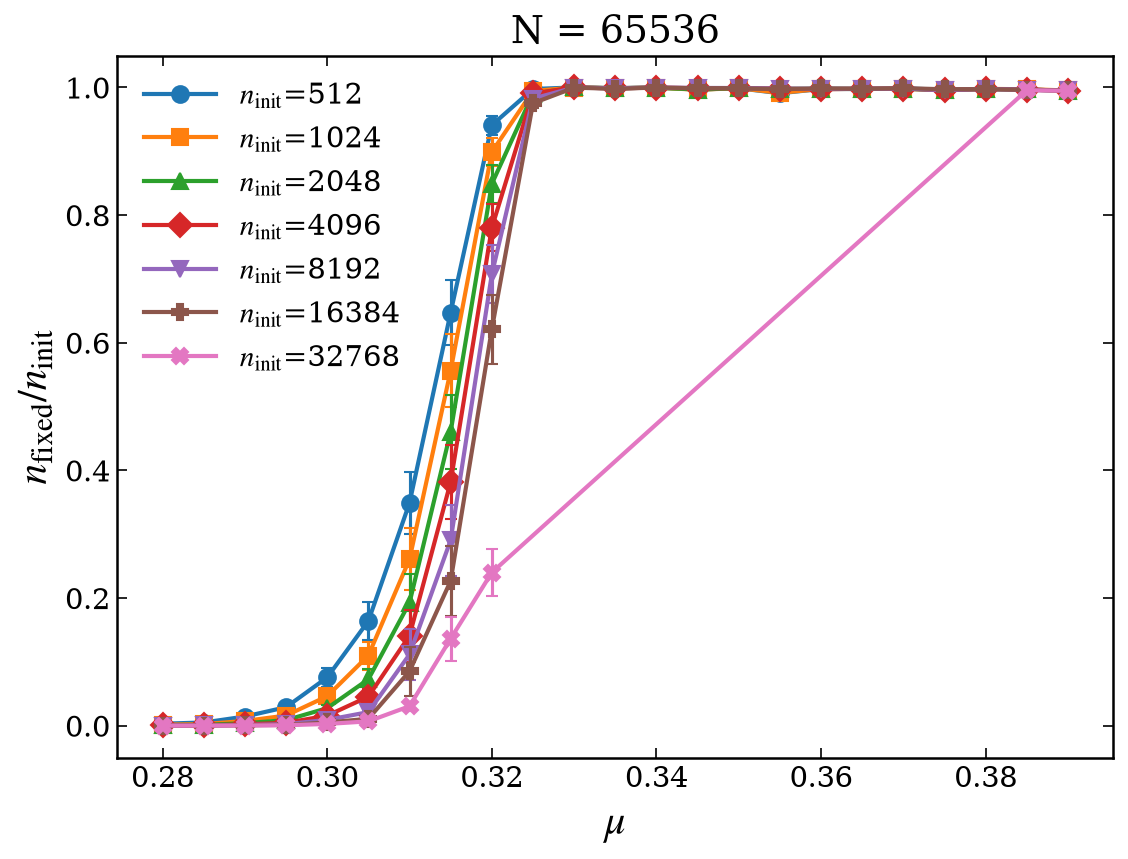

In [8]:
ninitcond_values = [512, 1024, 2048, 4096, 8192, 16384, 32768]
N_values = np.unique(data_nfixedpoints[:, 1])

for N in N_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, N, ninitcond_values, pos_filter=1, 
                              pos_param=2, pos_xplot=0, label_param=r"$n_{\rm init}$", type_param=int,
                              plot_title="N = " + str(int(N)),
                              xlabel=r"$\mu$", logscalex=False)

# $P(q)$ distributions (pairwise distances between fixed points)

In [58]:
import os
import re

In [59]:
def read_Pq_histogram_file(filepath):
    n_seeds = None
    with open(filepath) as f:
        for line in f:
            if not line.startswith('#'):
                break
            m = re.search(r'pooled (\d+) file', line)
            if m:
                n_seeds = int(m.group(1))
    data = np.loadtxt(filepath, comments='#')
    return data, n_seeds

In [60]:
def aggregate_Pq_bins(data, nbins_plot, exclude_zero=True):
    bin_left_file = data[:, 0]
    bin_right_file = data[:, 1]
    bin_center_file = data[:, 2]
    count_file = data[:, 3]

    if exclude_zero:
        mask = bin_left_file > 0
        bin_left_file = bin_left_file[mask]
        bin_right_file = bin_right_file[mask]
        bin_center_file = bin_center_file[mask]
        count_file = count_file[mask]

    nbins_file = bin_left_file.shape[0]
    if nbins_plot > nbins_file:
        raise ValueError(f"nbins_plot ({nbins_plot}) cannot exceed the number of bins "
                         f"available in the datafile ({nbins_file})")

    min_dist = bin_left_file[0]
    max_dist = bin_right_file[-1]
    total_weight = count_file.sum()

    edges = np.linspace(min_dist, max_dist, nbins_plot + 1)
    count, _ = np.histogram(bin_center_file, bins=edges, weights=count_file)

    bin_width = edges[1] - edges[0]
    density = count / (total_weight * bin_width) if total_weight > 0 else np.zeros_like(count)
    return edges, density

In [61]:
def check_pair_count(label, data, n_seeds, K):
    if n_seeds is None:
        print(f"  [warn] {label}: could not determine the number of pooled seeds; "
              f"skipping pair-count check")
        return
    expected = n_seeds * K * (K - 1) // 2
    actual = int(round(data[:, 3].sum()))
    if actual != expected:
        print(f"  [MISMATCH] {label}: total={actual}, expected {n_seeds} seed(s) x "
              f"C({K},2)={expected}")

In [62]:
def plot_Pq_histogram(raw_by_N, nbins_plot, K_ninitcond, eps=None, sigma=None, mu=None,
                      plot_title=None, xmin=None, xmax=None, ymin=None, ymax=None,
                      figsize=(8, 6), dpi=150, legend_loc='best', ncols_legend=1,
                      xlabel="q", ylabel="P(q)", title_fontsize=18, label_fontsize=20,
                      tick_fontsize=14, legend_fontsize=14, save_to=None,
                      linewidth=2, color_offset=0, legend_title="N",
                      logscalex=False, logscaley=True, exclude_zero=True):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.subplots_adjust(left=0.15, bottom=0.14, right=0.98, top=0.92)

    for idx, N in enumerate(sorted(raw_by_N)):
        data, n_seeds = raw_by_N[N]
        check_pair_count(f"eps={eps} sigma={sigma} mu={mu} N={N}", data, n_seeds, K_ninitcond)
        edges, density = aggregate_Pq_bins(data, nbins_plot, exclude_zero=exclude_zero)
        color = color_cycle[(idx + color_offset) % len(color_cycle)]
        ax.stairs(density, edges, fill=False, color=color, linewidth=linewidth, label=f"N={N}")

    if logscalex:
        ax.set_xscale('log')
    if logscaley:
        ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    if plot_title is not None:
        ax.set_title(plot_title, fontsize=title_fontsize)

    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5,
              ncol=ncols_legend, title=legend_title)

    if save_to is not None:
        plt.savefig(save_to)
    plt.show()

In [63]:
FILENAME_Pq_RE = re.compile(
    r"eps_(?P<eps>[0-9.eE+-]+)_mu_(?P<mu>[0-9.eE+-]+)_sigma_(?P<sigma>[0-9.eE+-]+)"
    r"_N_(?P<N>\d+)_c_(?P<c>[0-9.eE+-]+)"
    r"_Lotka_Volterra_final_av0_(?P<av0>[0-9.eE+-]+)_dn_(?P<dn>[0-9.eE+-]+)"
    r"_ninitcond_(?P<ninitcond>\d+)_tol_(?P<tol>[0-9.eE+-]+)_maxiter_(?P<maxiter>\d+)"
    r"_damping_(?P<damping>[0-9.eE+-]+)_pairwise_dist_histogram_nbins_(?P<nbins>\d+)\.txt$"
)

def find_Pq_histogram_files(path_in):
    entries = []
    for filename in os.listdir(path_in):
        m = FILENAME_Pq_RE.search(filename)
        if m is None:
            continue
        d = m.groupdict()
        entries.append({
            'eps': float(d['eps']), 'sigma': float(d['sigma']), 'mu': float(d['mu']),
            'N': int(d['N']), 'nbins_file': int(d['nbins']),
            'filepath': os.path.join(path_in, filename),
        })
    return entries

In [64]:
path_in_Pq = "/run/media/david/Data/Research/Ecology/Results/IBMF/Counting_fixed_points/Pq_histograms"

In [65]:
entries = find_Pq_histogram_files(path_in_Pq)

groups = {}
for e in entries:
    key = (e['eps'], e['sigma'], e['mu'])
    by_N = groups.setdefault(key, {})
    N = e['N']
    if N not in by_N or e['nbins_file'] > by_N[N]['nbins_file']:
        by_N[N] = e

Pq_raw_data = {}
for key, by_N in groups.items():
    raw_by_N = {}
    for N, entry in by_N.items():
        data, n_seeds = read_Pq_histogram_file(entry['filepath'])
        raw_by_N[N] = (data, n_seeds)
    Pq_raw_data[key] = raw_by_N

In [66]:
print("Available (eps, sigma, mu) sets:")
for key in sorted(Pq_raw_data):
    print(" ", key)

Available (eps, sigma, mu) sets:
  (0.0, 0.0, 0.37)
  (0.0, 0.0, 0.38)
  (0.0, 0.15, 0.33)
  (0.0, 0.15, 0.35)


  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=1024: total=20951049, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=2048: total=20762032, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=4096: total=20311583, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=8192: total=17384288, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=16384: total=9138096, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=32768: total=758849, expected 6 seed(s) x C(2048,2)=12576768
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.37 N=65536: total=1485, expected 1 seed(s) x C(2048,2)=2096128


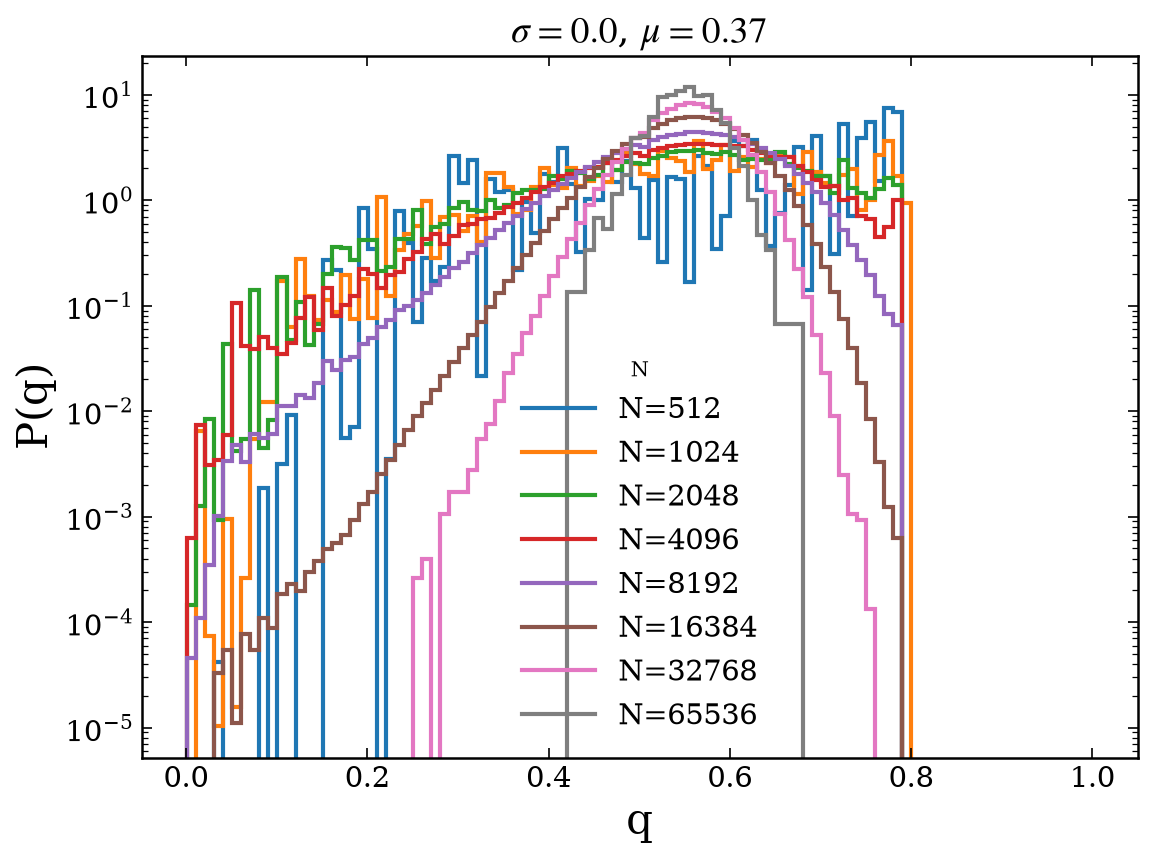

In [67]:
eps, sigma, mu = sorted(Pq_raw_data)[0]  # pick the (eps, sigma, mu) set to plot; duplicate this
                                         # cell (and change the tuple above) for each set you want
                                         # to inspect, so every figure keeps its own axis limits,
                                         # bin count, and K_ninitcond
nbins_plot = 100  # number of bins for this figure; must be <= the number of bins in the datafile
K_ninitcond = 2048  # expected number of initial conditions per seed, used for the pair-count check

plot_Pq_histogram(Pq_raw_data[(eps, sigma, mu)], nbins_plot=nbins_plot, K_ninitcond=K_ninitcond,
                  eps=eps, sigma=sigma, mu=mu, plot_title=rf"$\sigma={sigma}$, $\mu={mu}$",
                  xmin=None, xmax=None, ymin=None, ymax=None)

  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=512: total=20722780, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=1024: total=20955139, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=2048: total=20940813, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=4096: total=20816207, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=8192: total=20166484, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=16384: total=13301434, expected 8 seed(s) x C(2048,2)=16769024
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=32768: total=4789049, expected 6 seed(s) x C(2048,2)=12576768
  [MISMATCH] eps=0.0 sigma=0.0 mu=0.38 N=65536: total=126756, expected 1 seed(s) x C(2048,2)=2096128


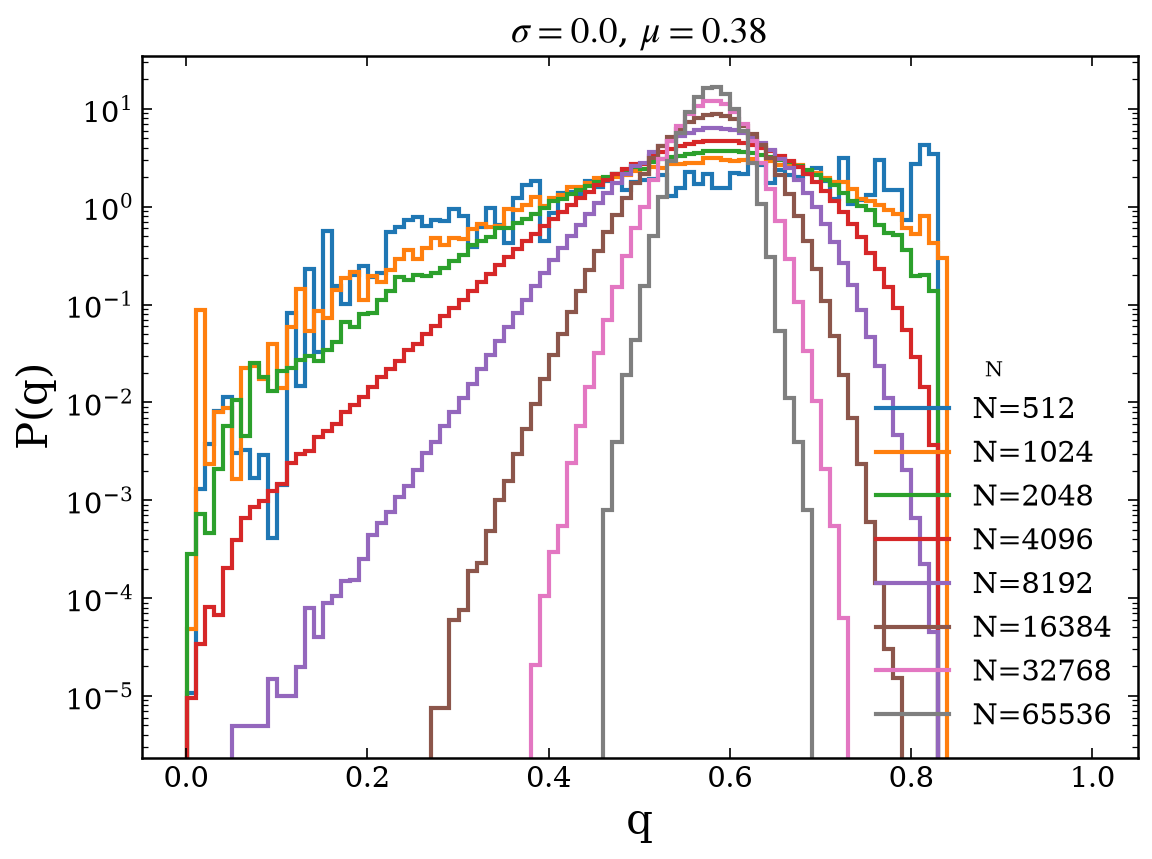

In [68]:
eps, sigma, mu = sorted(Pq_raw_data)[1]  # pick the (eps, sigma, mu) set to plot; duplicate this
                                         # cell (and change the tuple above) for each set you want
                                         # to inspect, so every figure keeps its own axis limits,
                                         # bin count, and K_ninitcond
nbins_plot = 100  # number of bins for this figure; must be <= the number of bins in the datafile
K_ninitcond = 2048  # expected number of initial conditions per seed, used for the pair-count check

plot_Pq_histogram(Pq_raw_data[(eps, sigma, mu)], nbins_plot=nbins_plot, K_ninitcond=K_ninitcond,
                  eps=eps, sigma=sigma, mu=mu, plot_title=rf"$\sigma={sigma}$, $\mu={mu}$",
                  xmin=None, xmax=None, ymin=None, ymax=None)

  [MISMATCH] eps=0.0 sigma=0.15 mu=0.33 N=65536: total=20951055, expected 10 seed(s) x C(2048,2)=20961280


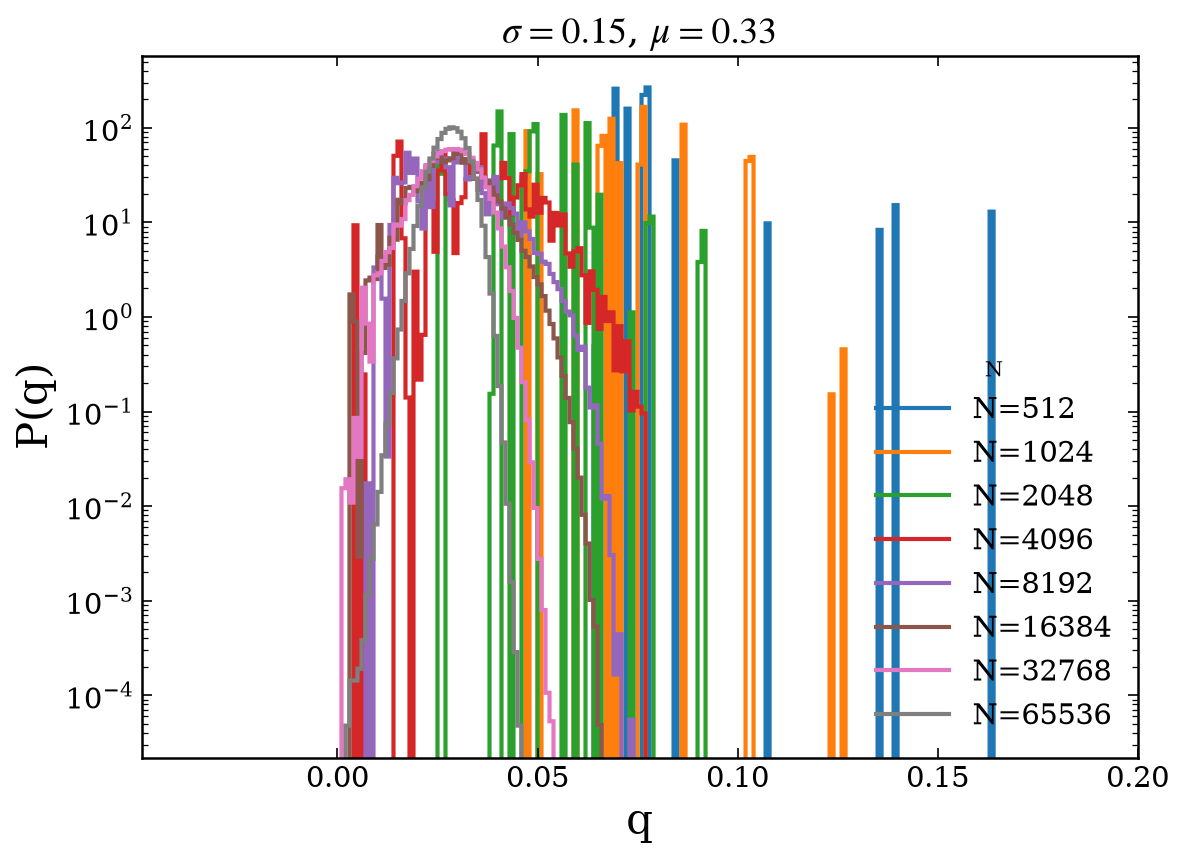

In [73]:
eps, sigma, mu = sorted(Pq_raw_data)[2]  # pick the (eps, sigma, mu) set to plot; duplicate this
                                         # cell (and change the tuple above) for each set you want
                                         # to inspect, so every figure keeps its own axis limits,
                                         # bin count, and K_ninitcond
nbins_plot = 999  # number of bins for this figure; must be <= the number of bins in the datafile
K_ninitcond = 2048  # expected number of initial conditions per seed, used for the pair-count check

plot_Pq_histogram(Pq_raw_data[(eps, sigma, mu)], nbins_plot=nbins_plot, K_ninitcond=K_ninitcond,
                  eps=eps, sigma=sigma, mu=mu, plot_title=rf"$\sigma={sigma}$, $\mu={mu}$",
                  xmin=None, xmax=0.2, ymin=None, ymax=None)

  [MISMATCH] eps=0.0 sigma=0.15 mu=0.35 N=16384: total=20959233, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.15 mu=0.35 N=32768: total=20957186, expected 10 seed(s) x C(2048,2)=20961280
  [MISMATCH] eps=0.0 sigma=0.15 mu=0.35 N=65536: total=20916339, expected 10 seed(s) x C(2048,2)=20961280


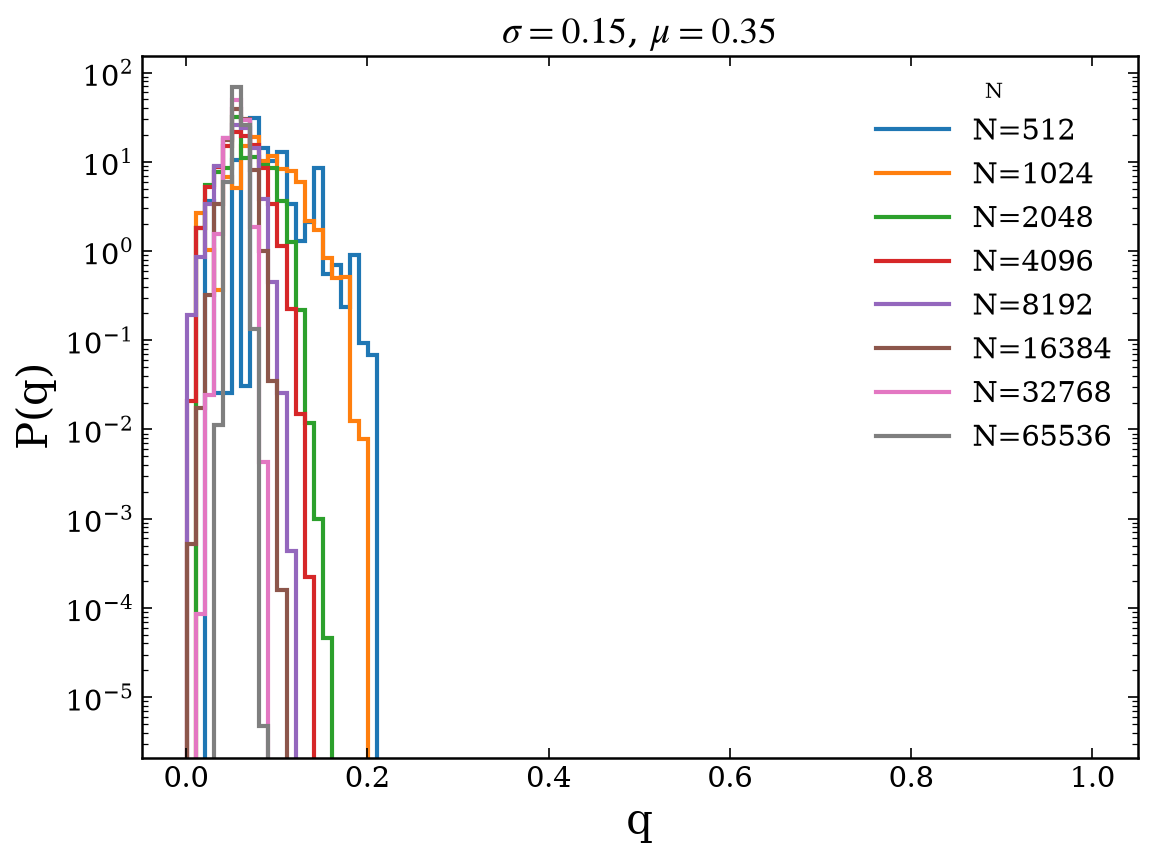

In [70]:
eps, sigma, mu = sorted(Pq_raw_data)[3]  # pick the (eps, sigma, mu) set to plot; duplicate this
                                         # cell (and change the tuple above) for each set you want
                                         # to inspect, so every figure keeps its own axis limits,
                                         # bin count, and K_ninitcond
nbins_plot = 100  # number of bins for this figure; must be <= the number of bins in the datafile
K_ninitcond = 2048  # expected number of initial conditions per seed, used for the pair-count check

plot_Pq_histogram(Pq_raw_data[(eps, sigma, mu)], nbins_plot=nbins_plot, K_ninitcond=K_ninitcond,
                  eps=eps, sigma=sigma, mu=mu, plot_title=rf"$\sigma={sigma}$, $\mu={mu}$",
                  xmin=None, xmax=None, ymin=None, ymax=None)